In [28]:
# 02 Risk Score Modeling 에 필요한 라이브러리 불러오기
# Logistic Regression + Negative Binomial

import os
import pandas as pd
import numpy as np
import geopandas as gpd
import unicodedata

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns

# 02. Risk Score Modeling

본 노트북에서는 4개 신도시 데이터를 이용하여 격자 단위 사고 위험지표를 학습하고,  
이를 하남교산에 적용하기 위한 입력 데이터셋을 구축한다.

전체 절차는 다음과 같다.

1. 4개 신도시와 하남교산의 기준 격자 데이터를 불러온다.
2. 교통사고 이력을 4개 신도시 격자에 매핑하여 학습용 타깃(`acc_cnt`, `acc_binary`)을 생성한다.
3. 인구, 도로, 교통, 시설물, 토지이용 관련 feature를 격자 단위로 집계한다.
4. 4개 신도시 학습용 feature table과 하남교산 적용용 feature table을 동일한 구조로 만든다.
5. 이후 Logistic Regression과 Negative Binomial 모델을 이용해 사고 위험지표를 산출한다.

이 단계에서는 먼저 **격자 기준 기본 테이블과 사고 타깃 변수**를 구축한다.

## 모델링 단계 요약

최종 목표 : **기존 4개의 신도시**에서 위험 지표를 학습해서, **하남 교산에 적용하자**

1. 데이터 로드
2. 격자 Feature 생성
3. 사고 데이터 결합
4. 학습 데이터 생성
5. Logistic 모델
6. NB 모델 
7. Risk Score 생성
8. 하남교산 적용

- 다음과 같은 파이프라인의 순서로 진행된다.

In [25]:
# 데이터셋 폴더 확인

ORIDATA_DIR = "../dataset"
DATA_DIR = "../outputs/processed"

print("원본 데이터셋")
for f in sorted(os.listdir(ORIDATA_DIR)):
    print(f)

print("\n전처리된 데이터셋")
for f in sorted(os.listdir(DATA_DIR)):
    print(f)

원본 데이터셋
.ipynb_checkpoints
01._격자_(4개_시·구).geojson
02._격자_(하남교산).geojson
03._성연령별_거주인구(격자).csv
04._성연령별_유동인구.csv
05._시간대별_직장인구.csv
06._시간대별_방문인구.csv
07._주중주말_서비스인구.csv
08.상세도로망_네트워크.geojson
09._평균속도.csv
10._추정교통량.csv
11._혼잡빈도강도.csv
12._혼잡시간강도.csv
13._교통사고이력.geojson
14._어린이보호구역.csv
15._학교현황.csv
16._유치원현황.csv
17._어린이집현황.csv
18._횡단보도_위치정보.csv
19._버스정류장_위치정보.csv
20._CCTV_현황.csv
21._과속방지턱_현황.csv
22._토지이용계획도_(4개_신도시).geojson
23._토지이용계획도_(하남교산).geojson
24._(참고자료)하남교산_공공주택지구_지구계획_변경(4차)_승인_고시문.pdf
25._교통데이터_코드표.csv
데이터셋 불러오기.ipynb

전처리된 데이터셋
01-01.거주인구_관련_부분.csv
04_flow_population_processed.csv
04_flow_population_with_gid.csv
05_working_population_processed.csv
06_visit_population_processed.csv
07_service_population_processed.csv
14._어린이보호구역_revised.csv
15._학교현황_revised.csv
16._유치원현황_revised.csv
17._어린이집현황_revised.csv
18._횡단보도_위치정보_revised.csv
19._버스정류장_위치정보_revised.csv
20._CCTV_현황_revised.csv
21._과속방지턱_현황_revised.csv
4개 신도시 격자단위 거주인구.csv
56._시간대별_유동인구.csv
gyosan_risk_score.csv

In [26]:
## 파일 경로 설정
# 파일명 직접 비교를 위해 정규화를 거쳐 안전하게 찾기 위한 전처리 과정

def norm_text(s):
    return unicodedata.normalize("NFC", str(s)).replace(" ", "")

def list_files(base_dir):
    return [f for f in os.listdir(base_dir) if not f.startswith(".")]

def find_by_startswith(base_dir, prefix, ext=None):
    files = list_files(base_dir)
    prefix_n = norm_text(prefix)
    cands = []
    for f in files:
        fn = norm_text(f)
        if fn.startswith(prefix_n):
            if ext is None or fn.endswith(ext):
                cands.append(f)
    if not cands:
        raise FileNotFoundError(f"prefix='{prefix}' 파일을 찾지 못함 in {base_dir}")
    if len(cands) > 1:
        print(f"[INFO] startswith 후보 여러 개: {cands} → 첫 번째 사용")
    return os.path.join(base_dir, cands[0])

def find_by_keywords(base_dir, keywords, ext=None):
    files = list_files(base_dir)
    kw = [norm_text(k) for k in keywords]
    cands = []
    for f in files:
        fn = norm_text(f)
        ok = all(k in fn for k in kw)
        if ok and (ext is None or fn.endswith(ext)):
            cands.append(f)
    if not cands:
        raise FileNotFoundError(f"keywords={keywords} 파일을 찾지 못함 in {base_dir}")
    if len(cands) > 1:
        print(f"[INFO] keyword 후보 여러 개: {cands} → 첫 번째 사용")
    return os.path.join(base_dir, cands[0])

In [29]:
# =========================
# 원본 데이터셋
# =========================
GRID4_FP   = find_by_startswith(ORIDATA_DIR, "01._격자_", ".geojson")
GRIDG_FP   = find_by_keywords(ORIDATA_DIR, ["02._격자_", "하남교산"], ".geojson")
ACC_FP     = find_by_startswith(ORIDATA_DIR, "13._교통사고이력", ".geojson")

ROAD_FP    = find_by_startswith(ORIDATA_DIR, "08.상세도로망", ".geojson")
SPEED_FP   = find_by_startswith(ORIDATA_DIR, "09._평균속도", ".csv")
TRAFFIC_FP = find_by_startswith(ORIDATA_DIR, "10._추정교통량", ".csv")
CF_FP      = find_by_startswith(ORIDATA_DIR, "11._혼잡빈도강도", ".csv")
CT_FP      = find_by_startswith(ORIDATA_DIR, "12._혼잡시간강도", ".csv")

LAND4_FP   = find_by_keywords(ORIDATA_DIR, ["22._토지이용계획도_", "4개"], ".geojson")
LANDG_FP   = find_by_keywords(ORIDATA_DIR, ["23._토지이용계획도_", "하남교산"], ".geojson")

# =========================
# 전처리 데이터셋
# =========================
POP4_FP    = find_by_keywords(DATA_DIR, ["4개", "신도시", "격자단위", "거주인구"], ".csv")
POPG_FP    = find_by_keywords(DATA_DIR, ["하남교산", "격자단위", "거주인구"], ".csv")

FLOW_FP    = find_by_startswith(DATA_DIR, "56._시간대별_유동인구", ".csv")
WORK_FP    = find_by_keywords(DATA_DIR, ["05", "working", "processed"], ".csv")
VISIT_FP   = find_by_keywords(DATA_DIR, ["06", "visit", "processed"], ".csv")
SERVICE_FP = find_by_keywords(DATA_DIR, ["07", "service", "processed"], ".csv")

CW_FP      = find_by_keywords(DATA_DIR, ["18._횡단보도", "revised"], ".csv")
BUS_FP     = find_by_keywords(DATA_DIR, ["19._버스정류장", "revised"], ".csv")
SCHOOL_FP  = find_by_keywords(DATA_DIR, ["15._학교현황", "revised"], ".csv")
KINDER_FP  = find_by_keywords(DATA_DIR, ["16._유치원현황", "revised"], ".csv")
DAYCARE_FP = find_by_keywords(DATA_DIR, ["17._어린이집현황", "revised"], ".csv")
CCTV_FP    = find_by_keywords(DATA_DIR, ["20._CCTV", "revised"], ".csv")
BUMP_FP    = find_by_keywords(DATA_DIR, ["21._과속방지턱", "revised"], ".csv")

print("GRID4_FP  =", GRID4_FP)
print("GRIDG_FP  =", GRIDG_FP)
print("ACC_FP    =", ACC_FP)
print("POP4_FP   =", POP4_FP)
print("POPG_FP   =", POPG_FP)
print("FLOW_FP   =", FLOW_FP)
print("WORK_FP   =", WORK_FP)
print("VISIT_FP  =", VISIT_FP)
print("SERVICE_FP=", SERVICE_FP)

GRID4_FP  = ../dataset/01._격자_(4개_시·구).geojson
GRIDG_FP  = ../dataset/02._격자_(하남교산).geojson
ACC_FP    = ../dataset/13._교통사고이력.geojson
POP4_FP   = ../outputs/processed/4개 신도시 격자단위 거주인구.csv
POPG_FP   = ../outputs/processed/하남교산 격자단위 거주인구.csv
FLOW_FP   = ../outputs/processed/56._시간대별_유동인구.csv
WORK_FP   = ../outputs/processed/05_working_population_processed.csv
VISIT_FP  = ../outputs/processed/06_visit_population_processed.csv
SERVICE_FP= ../outputs/processed/07_service_population_processed.csv


In [30]:
## 기준 격자로드
# 모든 feature는 최종적으로 'gid' 기준으로 집계를 해야하기에
# 먼저 4개 신도시 학습용 격자와 하남교산 적용용 격자를 기준 테이블로 불러온다

grid4 = gpd.read_file(GRID4_FP)
gridg = gpd.read_file(GRIDG_FP)

# 컬럼 정리
if "gbn" in grid4.columns:
    grid4 = grid4.rename(columns={"gbn": "city"})
if "gbn" in gridg.columns:
    gridg = gridg.rename(columns={"gbn": "city"})

grid4 = grid4[["gid", "city", "geometry"]].drop_duplicates()
gridg = gridg[["gid", "city", "geometry"]].drop_duplicates()

# CRS 통일
grid4 = grid4.set_crs("EPSG:4326", allow_override=True) if grid4.crs is None else grid4.to_crs("EPSG:4326")
gridg = gridg.set_crs("EPSG:4326", allow_override=True) if gridg.crs is None else gridg.to_crs("EPSG:4326")

print("grid4:", grid4.shape, grid4.crs)
print("gridg:", gridg.shape, gridg.crs)
display(grid4.head())
display(gridg.head())

grid4: (99323, 3) EPSG:4326
gridg: (770, 3) EPSG:4326


,gid,city,geometry
0,다사581304,경기도 성남시,"POLYGON ((127.02677 37.37172, 127.02677 37.372..."
1,다사581305,경기도 성남시,"POLYGON ((127.02677 37.37262, 127.02676 37.373..."
2,다사581306,경기도 성남시,"POLYGON ((127.02676 37.37352, 127.02676 37.374..."
3,다사582304,경기도 성남시,"POLYGON ((127.02790 37.37173, 127.02790 37.372..."
4,다사582305,경기도 성남시,"POLYGON ((127.02790 37.37263, 127.02789 37.373..."


,gid,city,geometry
0,다사720443,경기도 하남시,"POLYGON ((127.18323 37.49754, 127.18323 37.498..."
1,다사720444,경기도 하남시,"POLYGON ((127.18323 37.49844, 127.18323 37.499..."
2,다사721443,경기도 하남시,"POLYGON ((127.18436 37.49754, 127.18436 37.498..."
3,다사721444,경기도 하남시,"POLYGON ((127.18436 37.49844, 127.18436 37.499..."
4,다사721445,경기도 하남시,"POLYGON ((127.18436 37.49934, 127.18435 37.500..."


### 사고 데이터 매핑 및 학습용 타깃 생성

교통사고 포인트 데이터를 4개 신도시 격자에 spatial join하여  
격자별 사고 건수(`acc_cnt`)와 사고 발생 여부(`acc_binary`)를 생성한다.

이 두 변수는 이후 각각

- Logistic Regression의 종속변수 (`acc_binary`)
- Negative Binomial의 종속변수 (`acc_cnt`)

로 사용된다.

In [31]:
acc = gpd.read_file(ACC_FP)
acc = acc.set_crs("EPSG:4326", allow_override=True) if acc.crs is None else acc.to_crs("EPSG:4326")

acc = acc[acc.geometry.notna()].copy()
if acc.geometry.geom_type.nunique() > 1:
    acc = acc[acc.geometry.geom_type == "Point"].copy()

acc_join = gpd.sjoin(
    acc,
    grid4[["gid", "geometry"]],
    how="left",
    predicate="within"
).drop(columns=["index_right"], errors="ignore")

print("사고 총건수:", len(acc))
print("격자 매핑 성공:", acc_join["gid"].notna().sum())
print("격자 매핑 실패:", acc_join["gid"].isna().sum())

acc_cnt = (
    acc_join.dropna(subset=["gid"])
    .groupby("gid", as_index=False)
    .size()
    .rename(columns={"size": "acc_cnt"})
)

train_base = grid4.merge(acc_cnt, on="gid", how="left")
train_base["acc_cnt"] = train_base["acc_cnt"].fillna(0).astype(int)
train_base["acc_binary"] = (train_base["acc_cnt"] > 0).astype(int)

print("학습용 base shape:", train_base.shape)
display(train_base.head())

사고 총건수: 10821
격자 매핑 성공: 10934
격자 매핑 실패: 1
학습용 base shape: (99323, 5)


,gid,city,geometry,acc_cnt,acc_binary
0,다사581304,경기도 성남시,"POLYGON ((127.02677 37.37172, 127.02677 37.372...",0,0
1,다사581305,경기도 성남시,"POLYGON ((127.02677 37.37262, 127.02676 37.373...",0,0
2,다사581306,경기도 성남시,"POLYGON ((127.02676 37.37352, 127.02676 37.374...",0,0
3,다사582304,경기도 성남시,"POLYGON ((127.02790 37.37173, 127.02790 37.372...",0,0
4,다사582305,경기도 성남시,"POLYGON ((127.02790 37.37263, 127.02789 37.373...",0,0


### 거주인구 feature 결합

전처리 단계에서 구축한

- 4개 신도시 격자단위 거주인구
- 하남교산 격자단위 거주인구

를 각각 결합하여 `resident_pop` feature를 만든다.

이 변수는 기본적인 인구 노출도(exposure)를 설명하는 핵심 변수이다.

In [32]:
pop4 = pd.read_csv(POP4_FP)
popg = pd.read_csv(POPG_FP)

print("pop4 columns:", pop4.columns.tolist())
print("popg columns:", popg.columns.tolist())

pop4 columns: ['gid', 'gbn', 'newtown', 'blockType', 'resident_pop_reallocated']
popg columns: ['gid', 'gbn', 'blockType', 'block_pop_mean', 'res_factor', 'adjusted_weight', 'weight_ratio', 'resident_pop']


In [33]:
def standardize_resident(df):
    out = df.copy()

    if "resident_pop" in out.columns:
        return out

    candidates = [
        "resident_pop_reallocated",
        "allocated_pop",
        "resident_pop_est",
        "pop_est",
    ]
    for c in candidates:
        if c in out.columns:
            out = out.rename(columns={c: "resident_pop"})
            return out

    # 자동 후보
    cand = [c for c in out.columns if ("resident" in c.lower()) or ("pop" in c.lower() and c != "gid")]
    if len(cand) >= 1:
        print("[INFO] resident_pop 후보 자동 선택:", cand[0])
        out = out.rename(columns={cand[0]: "resident_pop"})
        return out

    raise ValueError("resident_pop 컬럼을 찾지 못함")

pop4 = standardize_resident(pop4)
popg = standardize_resident(popg)

pop4_feat = pop4[["gid", "resident_pop"]].drop_duplicates()
popg_feat = popg[["gid", "resident_pop"]].drop_duplicates()

train_base = train_base.merge(pop4_feat, on="gid", how="left")
pred_base = gridg.merge(popg_feat, on="gid", how="left")

train_base["resident_pop"] = train_base["resident_pop"].fillna(0)
pred_base["resident_pop"] = pred_base["resident_pop"].fillna(0)

display(train_base.head())
display(pred_base.head())

,gid,city,geometry,acc_cnt,acc_binary,resident_pop
0,다사581304,경기도 성남시,"POLYGON ((127.02677 37.37172, 127.02677 37.372...",0,0,0.0
1,다사581305,경기도 성남시,"POLYGON ((127.02677 37.37262, 127.02676 37.373...",0,0,0.0
2,다사581306,경기도 성남시,"POLYGON ((127.02676 37.37352, 127.02676 37.374...",0,0,0.0
3,다사582304,경기도 성남시,"POLYGON ((127.02790 37.37173, 127.02790 37.372...",0,0,0.0
4,다사582305,경기도 성남시,"POLYGON ((127.02790 37.37263, 127.02789 37.373...",0,0,0.0


,gid,city,geometry,resident_pop
0,다사720443,경기도 하남시,"POLYGON ((127.18323 37.49754, 127.18323 37.498...",47.607266
1,다사720443,경기도 하남시,"POLYGON ((127.18323 37.49754, 127.18323 37.498...",0.000000
2,다사720444,경기도 하남시,"POLYGON ((127.18323 37.49844, 127.18323 37.499...",47.607266
3,다사720444,경기도 하남시,"POLYGON ((127.18323 37.49844, 127.18323 37.499...",0.000000
4,다사721443,경기도 하남시,"POLYGON ((127.18436 37.49754, 127.18436 37.498...",0.000000


### 유동·직장·방문·서비스 인구 feature 준비

유동인구와 교통량 관련 변수는 사고 위험을 설명하는 데 매우 중요하다.  
다만 데이터셋마다 시간대 컬럼 구조가 다를 수 있으므로, 먼저 각 데이터셋에서 `gid` 기준으로 집계 가능한 총량 변수를 생성한다.

이 단계에서는 다음 변수를 만든다.

- `flow_pop`
- `working_pop`
- `visit_pop`
- `service_pop`

In [34]:
flow = pd.read_csv(FLOW_FP)
working = pd.read_csv(WORK_FP)
visit = pd.read_csv(VISIT_FP)
service = pd.read_csv(SERVICE_FP)

print("flow columns:", flow.columns.tolist())
print("working columns:", working.columns.tolist())
print("visit columns:", visit.columns.tolist())
print("service columns:", service.columns.tolist())

flow columns: ['gbn', 'STD_YM', 'lon', 'lat', 'gid', 'TMST_00', 'TMST_01', 'TMST_02', 'TMST_03', 'TMST_04', 'TMST_05', 'TMST_06', 'TMST_07', 'TMST_08', 'TMST_09', 'TMST_10', 'TMST_11', 'TMST_12', 'TMST_13', 'TMST_14', 'TMST_15', 'TMST_16', 'TMST_17', 'TMST_18', 'TMST_19', 'TMST_20', 'TMST_21', 'TMST_22', 'TMST_23', 'flow_0005', 'flow_0609', 'flow_1016', 'flow_1720', 'flow_2123']
working columns: ['gbn', 'STD_YM', 'TMST_00', 'TMST_01', 'TMST_02', 'TMST_03', 'TMST_04', 'TMST_05', 'TMST_06', 'TMST_07', 'TMST_08', 'TMST_09', 'TMST_10', 'TMST_11', 'TMST_12', 'TMST_13', 'TMST_14', 'TMST_15', 'TMST_16', 'TMST_17', 'TMST_18', 'TMST_19', 'TMST_20', 'TMST_21', 'TMST_22', 'TMST_23', 'lon', 'lat', 'gid']
visit columns: ['gbn', 'STD_YM', 'TMST_00', 'TMST_01', 'TMST_02', 'TMST_03', 'TMST_04', 'TMST_05', 'TMST_06', 'TMST_07', 'TMST_08', 'TMST_09', 'TMST_10', 'TMST_11', 'TMST_12', 'TMST_13', 'TMST_14', 'TMST_15', 'TMST_16', 'TMST_17', 'TMST_18', 'TMST_19', 'TMST_20', 'TMST_21', 'TMST_22', 'TMST_23', '

In [35]:
def make_gid_total_feature(df, gid_col="gid", out_name="value", preferred_cols=None, prefix_cols=None):
    tmp = df.copy()

    cols = []
    if preferred_cols is not None:
        cols = [c for c in preferred_cols if c in tmp.columns]

    if len(cols) == 0 and prefix_cols is not None:
        for p in prefix_cols:
            cols.extend([c for c in tmp.columns if c.startswith(p)])

    cols = list(dict.fromkeys(cols))

    if len(cols) == 0:
        raise ValueError(f"{out_name}: 집계할 컬럼을 찾지 못함")

    tmp[out_name] = tmp[cols].sum(axis=1)

    out = tmp.groupby(gid_col, as_index=False)[out_name].mean()
    return out, cols

# 56 유동인구
flow_feat, flow_used = make_gid_total_feature(
    flow,
    out_name="flow_pop",
    preferred_cols=["flow_0005", "flow_0609", "flow_1016", "flow_1720", "flow_2123"],
    prefix_cols=["TMST_", "flow_"]
)

# 05 직장인구
work_feat, work_used = make_gid_total_feature(
    working,
    out_name="working_pop",
    prefix_cols=["TMST_"]
)

# 06 방문인구
visit_feat, visit_used = make_gid_total_feature(
    visit,
    out_name="visit_pop",
    prefix_cols=["TMST_"]
)

# 07 서비스인구
service_tmp = service.copy()
if "w_total" in service_tmp.columns and "v_total" in service_tmp.columns:
    service_tmp["service_pop"] = service_tmp["w_total"] + service_tmp["v_total"]
else:
    num_cols = service_tmp.select_dtypes(include=np.number).columns.tolist()
    num_cols = [c for c in num_cols if c not in ["STD_YM"]]
    if len(num_cols) == 0:
        raise ValueError("service_pop 집계용 numeric 컬럼을 찾지 못함")
    service_tmp["service_pop"] = service_tmp[num_cols].sum(axis=1)

service_feat = service_tmp.groupby("gid", as_index=False)["service_pop"].mean()

print("flow 사용 컬럼:", flow_used)
print("working 사용 컬럼:", work_used[:10], "..." if len(work_used) > 10 else "")
print("visit 사용 컬럼:", visit_used[:10], "..." if len(visit_used) > 10 else "")
display(flow_feat.head())
display(work_feat.head())
display(visit_feat.head())
display(service_feat.head())

flow 사용 컬럼: ['flow_0005', 'flow_0609', 'flow_1016', 'flow_1720', 'flow_2123']
working 사용 컬럼: ['TMST_00', 'TMST_01', 'TMST_02', 'TMST_03', 'TMST_04', 'TMST_05', 'TMST_06', 'TMST_07', 'TMST_08', 'TMST_09'] ...
visit 사용 컬럼: ['TMST_00', 'TMST_01', 'TMST_02', 'TMST_03', 'TMST_04', 'TMST_05', 'TMST_06', 'TMST_07', 'TMST_08', 'TMST_09'] ...


,gid,flow_pop
0,다바154953,0.241973
1,다바154954,0.234171
2,다바154955,0.225015
3,다바155954,0.232749
4,다바155955,0.199885


,gid,working_pop
0,다바154953,0.019694
1,다바154954,0.001649
2,다바154955,0.000000
3,다바155954,0.000000
4,다바155955,0.147011


,gid,visit_pop
0,다바154953,0.222279
1,다바154954,0.232522
2,다바154955,0.225015
3,다바155954,0.232749
4,다바155955,0.052874


,gid,service_pop
0,다바154953,0.013687
1,다바154954,NaN
2,다바154955,NaN
3,다바155954,NaN
4,다바155955,0.017969


### 인구 feature 결합

앞서 집계한 유동·직장·방문·서비스 인구를 `gid` 기준으로 학습용 base table에 결합한다.

이 단계가 끝나면 최소한의 인구 노출도 기반 feature set이 완성된다.

In [36]:
for feat_df in [flow_feat, work_feat, visit_feat, service_feat]:
    train_base = train_base.merge(feat_df, on="gid", how="left")

for c in ["flow_pop", "working_pop", "visit_pop", "service_pop"]:
    train_base[c] = train_base[c].fillna(0)

display(train_base.head())
print(train_base.columns.tolist())

,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop
0,다사581304,경기도 성남시,"POLYGON ((127.02677 37.37172, 127.02677 37.372...",0,0,0.0,0.000000,0.000000,0.000000,0.0
1,다사581305,경기도 성남시,"POLYGON ((127.02677 37.37262, 127.02676 37.373...",0,0,0.0,0.031594,0.015572,0.016022,0.0
2,다사581306,경기도 성남시,"POLYGON ((127.02676 37.37352, 127.02676 37.374...",0,0,0.0,0.000000,0.000000,0.000000,0.0
3,다사582304,경기도 성남시,"POLYGON ((127.02790 37.37173, 127.02790 37.372...",0,0,0.0,0.022768,0.018269,0.004499,0.0
4,다사582305,경기도 성남시,"POLYGON ((127.02790 37.37263, 127.02789 37.373...",0,0,0.0,0.031655,0.016485,0.015169,0.0


['gid', 'city', 'geometry', 'acc_cnt', 'acc_binary', 'resident_pop', 'flow_pop', 'working_pop', 'visit_pop', 'service_pop']


### 현재까지의 학습용 feature table 점검

현재까지 구축된 학습용 테이블은 다음 정보를 포함한다.

- 기준 격자 (`gid`, `city`)
- 타깃 변수 (`acc_cnt`, `acc_binary`)
- 거주인구 (`resident_pop`)
- 유동인구 (`flow_pop`)
- 직장인구 (`working_pop`)
- 방문인구 (`visit_pop`)
- 서비스인구 (`service_pop`)

다음 단계에서는 여기에 도로·교통·시설물·토지이용 feature를 추가하여  
최종 모델 입력 테이블을 완성한다.

In [37]:
core_cols = [
    "gid", "city", "acc_cnt", "acc_binary",
    "resident_pop", "flow_pop", "working_pop", "visit_pop", "service_pop"
]

display(train_base[core_cols].head())
print(train_base[core_cols].describe(include="all"))

,gid,city,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop
0,다사581304,경기도 성남시,0,0,0.0,0.000000,0.000000,0.000000,0.0
1,다사581305,경기도 성남시,0,0,0.0,0.031594,0.015572,0.016022,0.0
2,다사581306,경기도 성남시,0,0,0.0,0.000000,0.000000,0.000000,0.0
3,다사582304,경기도 성남시,0,0,0.0,0.022768,0.018269,0.004499,0.0
4,다사582305,경기도 성남시,0,0,0.0,0.031655,0.016485,0.015169,0.0


             gid     city        acc_cnt     acc_binary   resident_pop  \
count     105032   105032  105032.000000  105032.000000  105032.000000   
unique     99146        4            NaN            NaN            NaN   
top     다사685420  경기도 화성시            NaN            NaN            NaN   
freq          16    74624            NaN            NaN            NaN   
mean         NaN      NaN       0.135797       0.069579       7.132262   
std          NaN      NaN       0.701094       0.254437      33.748294   
min          NaN      NaN       0.000000       0.000000       0.000000   
25%          NaN      NaN       0.000000       0.000000       0.000000   
50%          NaN      NaN       0.000000       0.000000       0.000000   
75%          NaN      NaN       0.000000       0.000000       0.000000   
max          NaN      NaN      24.000000       1.000000    1317.254606   

             flow_pop    working_pop      visit_pop    service_pop  
count   105032.000000  105032.000000  1050

In [38]:
# 중간 저장하기 코드
train_base.to_csv(
    os.path.join(DATA_DIR, "02_train_base_core_features.csv"),
    index=False,
    encoding="utf-8-sig"
)

pred_base.to_csv(
    os.path.join(DATA_DIR, "02_pred_base_core_features_gyosan.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")

저장 완료


### 도로 링크 기반 교통 Feature 생성

평균속도, 교통량, 혼잡 데이터는 격자 기준이 아니라  
도로 링크(v_link_id) 기준으로 제공된다.

따라서 다음 절차로 격자 단위 feature를 생성한다.

1. 도로망 데이터와 link_id 기준으로 merge
2. 도로 geometry를 이용하여 격자와 spatial join
3. 격자 단위 평균/합계로 집계

이를 통해 다음 변수들을 생성한다.

- mean_speed
- traffic_volume
- congestion_freq
- congestion_time

In [39]:
roads = gpd.read_file(ROAD_FP)

roads = roads.to_crs("EPSG:4326")
grid4 = grid4.to_crs("EPSG:4326")

# spatial join
road_join = gpd.sjoin(
    roads,
    grid4[["gid", "geometry"]],
    how="left",
    predicate="intersects"
)

# 길이 계산을 위해 meter CRS
road_join = road_join.to_crs("EPSG:5186")

road_join["road_len"] = road_join.geometry.length

road_feat = (
    road_join
    .groupby("gid", as_index=False)["road_len"]
    .sum()
    .rename(columns={"road_len":"road_length"})
)

road_feat.head()

,gid,road_length
0,다바293999,6195.914221
1,다바294998,6195.914221
2,다바294999,6195.914221
3,다바295997,6195.914221
4,다바295998,6195.914221


In [40]:
# 격자 면적 계산
grid_area = grid4.to_crs("EPSG:5186")

grid_area["area_m2"] = grid_area.geometry.area

area_feat = grid_area[["gid","area_m2"]]

In [41]:
# Road Density 확인하기
road_feat = road_feat.merge(area_feat, on="gid", how="left")

road_feat["road_density"] = road_feat["road_length"] / road_feat["area_m2"]

road_feat.head()

,gid,road_length,area_m2,road_density
0,다바293999,6195.914221,10006.943219,0.619162
1,다바294998,6195.914221,10006.945404,0.619161
2,다바294999,6195.914221,10006.945411,0.619161
3,다바295997,6195.914221,10006.947588,0.619161
4,다바295998,6195.914221,10006.947595,0.619161


In [42]:
# 교통 데이터 
speed = pd.read_csv(SPEED_FP)
traffic = pd.read_csv(TRAFFIC_FP)
cf = pd.read_csv(CF_FP)
ct = pd.read_csv(CT_FP)

print(speed.columns)
print(traffic.columns)
print(cf.columns)
print(ct.columns)

Index(['v_link_id', 'road_rank', 'k_length', 'sido_id', 'sigungu_id', 'emd_id',
       'sido_name', 'sigungu_name', 'emd_name', 'timeslot', 'velocity_AVRG',
       'probe'],
      dtype='object')
Index(['v_link_id', 'road_rank', 'k_length', 'sido_id', 'sigungu_id', 'emd_id',
       'sido_name', 'sigungu_name', 'emd_name', 'timeslot', 'ALL_AADT',
       'PSCR_AADT', 'BUS_AADT', 'FGCR_AADT'],
      dtype='object')
Index(['v_link_id', 'road_rank', 'k_length', 'sido_id', 'sigungu_id', 'emd_id',
       'sido_name', 'sigungu_name', 'emd_name', 'FRIN_CG'],
      dtype='object')
Index(['v_link_id', 'road_rank', 'k_length', 'sido_id', 'sigungu_id', 'emd_id',
       'sido_name', 'sigungu_name', 'emd_name', 'TI_CG'],
      dtype='object')


In [44]:
print("speed columns")
print(speed.columns)
print(speed.head())

print("\ntraffic columns")
print(traffic.columns)
print(traffic.head())

print("\ncf columns")
print(cf.columns)
print(cf.head())

print("\nct columns")
print(ct.columns)
print(ct.head())

speed columns
Index(['v_link_id', 'road_rank', 'k_length', 'sido_id', 'sigungu_id', 'emd_id',
       'sido_name', 'sigungu_name', 'emd_name', 'timeslot', 'velocity_AVRG',
       'probe'],
      dtype='object')
     v_link_id  road_rank  k_length  sido_id  sigungu_id    emd_id sido_name  \
0  57166862101        104     1.320    11000       11240  11240820     서울특별시   
1  57166862102        104     1.320    11000       11240  11240820     서울특별시   
2  57164847201        104     0.017    11000       11240  11240710     서울특별시   
3  57164847202        104     0.017    11000       11240  11240710     서울특별시   
4  57177182401        104     0.017    11000       11240  11240710     서울특별시   

  sigungu_name emd_name  timeslot  velocity_AVRG  probe  
0          송파구      위례동         0          63.87   2725  
1          송파구      위례동         0          48.48   4926  
2          송파구     잠실본동         0          30.31    438  
3          송파구     잠실본동         0          27.97    915  
4          송파구     

In [45]:
print("\nspeed shape:", speed.shape)
print("traffic shape:", traffic.shape)
print("cf shape:", cf.shape)
print("ct shape:", ct.shape)


speed shape: (926518, 12)
traffic shape: (926518, 14)
cf shape: (39451, 10)
ct shape: (39451, 10)


In [46]:
roads = gpd.read_file(ROAD_FP)

roads = roads.to_crs("EPSG:4326")

print(roads.columns)
display(roads.head())

Index(['link_id', 'up_f_node', 'up_t_node', 'dw_f_node', 'dw_t_node',
       'max_speed', 'road_name', 'road_no', 'road_rank', 'link_type',
       'pavement', 'road_type', 'facil_name', 'tg_name', 'up_lanes',
       'dw_lanes', 'lanes', 'oneway', 'length', 'level', 'up_its_id',
       'dw_its_id', 'sido_id', 'sigungu_id', 'emd_id', 'up_v_link',
       'dw_v_link', 'm_date', 'rc_id', 'rc_name', 'rc_hist', 'rc_date',
       'rc_length', 'old_link_i', 'geometry'],
      dtype='object')


,link_id,up_f_node,up_t_node,dw_f_node,dw_t_node,max_speed,road_name,road_no,road_rank,link_type,...,up_v_link,dw_v_link,m_date,rc_id,rc_name,rc_hist,rc_date,rc_length,old_link_i,geometry
0,475200018,181435,181436,181436,181435,40,해안길,0,107,32768,...,47520001801,47520001802,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61802 37.16365, 126.61934 37.1..."
1,475200026,181436,181444,181444,181436,40,해안길178번길,0,107,32768,...,47520002601,47520002602,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61934 37.16377, 126.61940 37.1..."
2,475200028,181437,181438,181438,181437,40,None,0,107,32768,...,47520002801,47520002802,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61848 37.16920, 126.61722 37.1..."
3,475200030,181517,181437,181437,181517,40,해안길178번길,0,107,32768,...,47520003001,47520003002,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61825 37.17026, 126.61842 37.1..."
4,475200032,181437,181440,181440,181437,40,해안길178번길,0,107,32768,...,47520003201,47520003202,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61848 37.16920, 126.61862 37.1..."


In [48]:
print("roads columns")
print(roads.columns.tolist())

display(roads.head())

roads columns
['link_id', 'up_f_node', 'up_t_node', 'dw_f_node', 'dw_t_node', 'max_speed', 'road_name', 'road_no', 'road_rank', 'link_type', 'pavement', 'road_type', 'facil_name', 'tg_name', 'up_lanes', 'dw_lanes', 'lanes', 'oneway', 'length', 'level', 'up_its_id', 'dw_its_id', 'sido_id', 'sigungu_id', 'emd_id', 'up_v_link', 'dw_v_link', 'm_date', 'rc_id', 'rc_name', 'rc_hist', 'rc_date', 'rc_length', 'old_link_i', 'geometry']


,link_id,up_f_node,up_t_node,dw_f_node,dw_t_node,max_speed,road_name,road_no,road_rank,link_type,...,up_v_link,dw_v_link,m_date,rc_id,rc_name,rc_hist,rc_date,rc_length,old_link_i,geometry
0,475200018,181435,181436,181436,181435,40,해안길,0,107,32768,...,47520001801,47520001802,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61802 37.16365, 126.61934 37.1..."
1,475200026,181436,181444,181444,181436,40,해안길178번길,0,107,32768,...,47520002601,47520002602,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61934 37.16377, 126.61940 37.1..."
2,475200028,181437,181438,181438,181437,40,None,0,107,32768,...,47520002801,47520002802,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61848 37.16920, 126.61722 37.1..."
3,475200030,181517,181437,181437,181517,40,해안길178번길,0,107,32768,...,47520003001,47520003002,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61825 37.17026, 126.61842 37.1..."
4,475200032,181437,181440,181440,181437,40,해안길178번길,0,107,32768,...,47520003201,47520003202,20171231,None,None,None,NaN,NaN,0.0,"LINESTRING (126.61848 37.16920, 126.61862 37.1..."


### 도로 링크 ID 정리

도로망 데이터에는 `v_link_id`가 직접 존재하지 않고,  
상행/하행 링크 ID인 `up_v_link`, `dw_v_link`가 분리되어 있다.

따라서 두 컬럼을 하나의 `v_link_id` 컬럼으로 통합한 뒤,  
교통 데이터(평균속도, 교통량, 혼잡빈도, 혼잡시간)와 연결한다.

In [49]:
# roads: up_v_link / dw_v_link 를 하나의 v_link_id로 통합
road_up = roads[["up_v_link", "geometry"]].copy()
road_up = road_up.rename(columns={"up_v_link": "v_link_id"})

road_dw = roads[["dw_v_link", "geometry"]].copy()
road_dw = road_dw.rename(columns={"dw_v_link": "v_link_id"})

road_links = pd.concat([road_up, road_dw], ignore_index=True)

# 결측 제거
road_links = road_links.dropna(subset=["v_link_id"]).copy()

# 타입 통일
road_links["v_link_id"] = pd.to_numeric(road_links["v_link_id"], errors="coerce")
road_links = road_links.dropna(subset=["v_link_id"]).copy()
road_links["v_link_id"] = road_links["v_link_id"].astype("int64")

road_links = gpd.GeoDataFrame(road_links, geometry="geometry", crs=roads.crs)

print("road_links shape:", road_links.shape)
display(road_links.head())

road_links shape: (48006, 2)


,v_link_id,geometry
0,47520001801,"LINESTRING (126.61802 37.16365, 126.61934 37.1..."
1,47520002601,"LINESTRING (126.61934 37.16377, 126.61940 37.1..."
2,47520002801,"LINESTRING (126.61848 37.16920, 126.61722 37.1..."
3,47520003001,"LINESTRING (126.61825 37.17026, 126.61842 37.1..."
4,47520003201,"LINESTRING (126.61848 37.16920, 126.61862 37.1..."


In [50]:
speed["v_link_id"] = pd.to_numeric(speed["v_link_id"], errors="coerce")
speed = speed.dropna(subset=["v_link_id"]).copy()
speed["v_link_id"] = speed["v_link_id"].astype("int64")

speed_link = road_links.merge(
    speed[["v_link_id", "velocity_AVRG"]],
    on="v_link_id",
    how="inner"
)

speed_link = gpd.GeoDataFrame(speed_link, geometry="geometry", crs=road_links.crs).to_crs("EPSG:4326")

speed_join = gpd.sjoin(
    speed_link,
    grid4[["gid", "geometry"]],
    how="left",
    predicate="intersects"
).drop(columns=["index_right"], errors="ignore")

speed_feat = (
    speed_join.dropna(subset=["gid"])
    .groupby("gid", as_index=False)["velocity_AVRG"]
    .mean()
    .rename(columns={"velocity_AVRG": "mean_speed"})
)

print("speed_feat shape:", speed_feat.shape)
display(speed_feat.head())

speed_feat shape: (26570, 2)


,gid,mean_speed
0,다바293999,58.28875
1,다바294998,58.28875
2,다바294999,58.28875
3,다바295997,58.28875
4,다바295998,58.28875


In [51]:
traffic["v_link_id"] = pd.to_numeric(traffic["v_link_id"], errors="coerce")
traffic = traffic.dropna(subset=["v_link_id"]).copy()
traffic["v_link_id"] = traffic["v_link_id"].astype("int64")

traffic_link = road_links.merge(
    traffic[["v_link_id", "ALL_AADT"]],
    on="v_link_id",
    how="inner"
)

traffic_link = gpd.GeoDataFrame(traffic_link, geometry="geometry", crs=road_links.crs).to_crs("EPSG:4326")

traffic_join = gpd.sjoin(
    traffic_link,
    grid4[["gid", "geometry"]],
    how="left",
    predicate="intersects"
).drop(columns=["index_right"], errors="ignore")

traffic_feat = (
    traffic_join.dropna(subset=["gid"])
    .groupby("gid", as_index=False)["ALL_AADT"]
    .mean()
    .rename(columns={"ALL_AADT": "traffic_volume"})
)

print("traffic_feat shape:", traffic_feat.shape)
display(traffic_feat.head())

traffic_feat shape: (26570, 2)


,gid,traffic_volume
0,다바293999,183.0
1,다바294998,183.0
2,다바294999,183.0
3,다바295997,183.0
4,다바295998,183.0


In [52]:
cf["v_link_id"] = pd.to_numeric(cf["v_link_id"], errors="coerce")
cf = cf.dropna(subset=["v_link_id"]).copy()
cf["v_link_id"] = cf["v_link_id"].astype("int64")

cf_link = road_links.merge(
    cf[["v_link_id", "FRIN_CG"]],
    on="v_link_id",
    how="inner"
)

cf_link = gpd.GeoDataFrame(cf_link, geometry="geometry", crs=road_links.crs).to_crs("EPSG:4326")

cf_join = gpd.sjoin(
    cf_link,
    grid4[["gid", "geometry"]],
    how="left",
    predicate="intersects"
).drop(columns=["index_right"], errors="ignore")

cf_feat = (
    cf_join.dropna(subset=["gid"])
    .groupby("gid", as_index=False)["FRIN_CG"]
    .mean()
    .rename(columns={"FRIN_CG": "congestion_freq"})
)

print("cf_feat shape:", cf_feat.shape)
display(cf_feat.head())

cf_feat shape: (26159, 2)


,gid,congestion_freq
0,다바293999,52.76
1,다바294998,52.76
2,다바294999,52.76
3,다바295997,52.76
4,다바295998,52.76


In [53]:
ct["v_link_id"] = pd.to_numeric(ct["v_link_id"], errors="coerce")
ct = ct.dropna(subset=["v_link_id"]).copy()
ct["v_link_id"] = ct["v_link_id"].astype("int64")

ct_link = road_links.merge(
    ct[["v_link_id", "TI_CG"]],
    on="v_link_id",
    how="inner"
)

ct_link = gpd.GeoDataFrame(ct_link, geometry="geometry", crs=road_links.crs).to_crs("EPSG:4326")

ct_join = gpd.sjoin(
    ct_link,
    grid4[["gid", "geometry"]],
    how="left",
    predicate="intersects"
).drop(columns=["index_right"], errors="ignore")

ct_feat = (
    ct_join.dropna(subset=["gid"])
    .groupby("gid", as_index=False)["TI_CG"]
    .mean()
    .rename(columns={"TI_CG": "congestion_time"})
)

print("ct_feat shape:", ct_feat.shape)
display(ct_feat.head())

ct_feat shape: (26159, 2)


,gid,congestion_time
0,다바293999,62.45
1,다바294998,62.45
2,다바294999,62.45
3,다바295997,62.45
4,다바295998,62.45


In [54]:
for feat in [speed_feat, traffic_feat, cf_feat, ct_feat]:
    train_base = train_base.merge(feat, on="gid", how="left")

for c in ["mean_speed", "traffic_volume", "congestion_freq", "congestion_time"]:
    train_base[c] = train_base[c].fillna(0)

display(train_base.head())
print(train_base[["mean_speed", "traffic_volume", "congestion_freq", "congestion_time"]].describe())

,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,mean_speed,traffic_volume,congestion_freq,congestion_time
0,다사581304,경기도 성남시,"POLYGON ((127.02677 37.37172, 127.02677 37.372...",0,0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,다사581305,경기도 성남시,"POLYGON ((127.02677 37.37262, 127.02676 37.373...",0,0,0.0,0.031594,0.015572,0.016022,0.0,0.0,0.0,0.0,0.0
2,다사581306,경기도 성남시,"POLYGON ((127.02676 37.37352, 127.02676 37.374...",0,0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
3,다사582304,경기도 성남시,"POLYGON ((127.02790 37.37173, 127.02790 37.372...",0,0,0.0,0.022768,0.018269,0.004499,0.0,0.0,0.0,0.0,0.0
4,다사582305,경기도 성남시,"POLYGON ((127.02790 37.37263, 127.02789 37.373...",0,0,0.0,0.031655,0.016485,0.015169,0.0,0.0,0.0,0.0,0.0


          mean_speed  traffic_volume  congestion_freq  congestion_time
count  105032.000000   105032.000000    105032.000000    105032.000000
mean       11.689898      149.340756        15.581925        19.524311
std        20.788614      397.591251        28.757228        33.676058
min         0.000000        0.000000         0.000000         0.000000
25%         0.000000        0.000000         0.000000         0.000000
50%         0.000000        0.000000         0.000000         0.000000
75%        21.718932      134.729167        15.440000        31.990000
max       100.447083     5403.833333       100.000000       100.000000


### 시설물 Feature 생성

교통사고 위험은 인구와 도로 환경뿐 아니라,  
보행 시설과 생활 인프라의 존재 여부에도 큰 영향을 받는다.

따라서 다음과 같은 시설물 데이터를 격자 단위로 집계하여 추가한다.

- `crosswalk_count` : 횡단보도 개수
- `bus_stop_count` : 버스정류장 개수
- `school_count` : 학교 개수
- `kinder_count` : 유치원 개수
- `daycare_count` : 어린이집 개수
- `cctv_count` : CCTV 개수
- `speedbump_count` : 과속방지턱 개수

이 변수들은 특히 보행자 사고, 어린이 보호구역 주변 사고, 생활권 내 교통안전 위험을 설명하는 데 유용하다.

In [55]:
cw = pd.read_csv(CW_FP)
bus = pd.read_csv(BUS_FP)
school = pd.read_csv(SCHOOL_FP)
kinder = pd.read_csv(KINDER_FP)
daycare = pd.read_csv(DAYCARE_FP)
cctv = pd.read_csv(CCTV_FP)
bump = pd.read_csv(BUMP_FP)

print("cw columns:", cw.columns.tolist())
print("bus columns:", bus.columns.tolist())
print("school columns:", school.columns.tolist())
print("kinder columns:", kinder.columns.tolist())
print("daycare columns:", daycare.columns.tolist())
print("cctv columns:", cctv.columns.tolist())
print("bump columns:", bump.columns.tolist())

cw columns: ['gbn', 'lon', 'lat']
bus columns: ['bis_id', 'stn_nm', 'lon', 'lat']
school columns: ['school_nm', 'school_gbn', 'estab_dt', 'estab_gbn', 'addr', 'lon', 'lat']
kinder columns: ['kinder_nm', 'estab_gbn', 'open_dt', 'appr_cap', 'age3_cnt', 'age4_cnt', 'age5_cnt', 'mix_cnt', 'spec_cnt', 'lon', 'lat', 'child_cnt_total', 'ratio', 'ratio_r2']
daycare columns: ['cc_name', 'cc_type', 'oper_stat', 'appr_dt', 'close_dt', 'bus_yn', 'appr_cap', 'curr_cnt', 'lon', 'lat', 'ratio', 'ratio_r2']
cctv columns: ['inst_purp', 'cam_cnt', 'inst_ym', 'lon', 'lat']
bump columns: ['gbn', 'addr', 'inst_plc', 'fac_hght', 'fac_wdth', 'sprtn', 'cntns', 'lon', 'lat', 'real']


#### 좌표 기반 시설물 데이터 처리

시설물 데이터는 대부분 위경도(`lon`, `lat`) 기반 점 데이터이므로,  
각 데이터를 Point geometry로 변환한 뒤 기준 격자와 spatial join하여 `gid`를 부여한다.

그 후 `gid`별 개수를 세어 시설물 count feature를 생성한다.

In [56]:
def make_point_gdf(df, lon_candidates=None, lat_candidates=None, crs="EPSG:4326"):
    tmp = df.copy()

    if lon_candidates is None:
        lon_candidates = ["lon", "x", "longitude", "경도"]
    if lat_candidates is None:
        lat_candidates = ["lat", "y", "latitude", "위도"]

    lon_col = None
    lat_col = None

    for c in lon_candidates:
        if c in tmp.columns:
            lon_col = c
            break

    for c in lat_candidates:
        if c in tmp.columns:
            lat_col = c
            break

    if lon_col is None or lat_col is None:
        raise ValueError(f"좌표 컬럼을 찾지 못함. columns={tmp.columns.tolist()}")

    tmp[lon_col] = pd.to_numeric(tmp[lon_col], errors="coerce")
    tmp[lat_col] = pd.to_numeric(tmp[lat_col], errors="coerce")
    tmp = tmp.dropna(subset=[lon_col, lat_col]).copy()

    gdf = gpd.GeoDataFrame(
        tmp,
        geometry=gpd.points_from_xy(tmp[lon_col], tmp[lat_col]),
        crs=crs
    )
    return gdf


def make_count_feature(point_gdf, grid_gdf, out_name):
    joined = gpd.sjoin(
        point_gdf.to_crs("EPSG:4326"),
        grid_gdf[["gid", "geometry"]].to_crs("EPSG:4326"),
        how="left",
        predicate="within"
    ).drop(columns=["index_right"], errors="ignore")

    feat = (
        joined.dropna(subset=["gid"])
        .groupby("gid", as_index=False)
        .size()
        .rename(columns={"size": out_name})
    )
    return feat

In [57]:
# Point 변환
cw_gdf = make_point_gdf(cw)
bus_gdf = make_point_gdf(bus)
school_gdf = make_point_gdf(school)
kinder_gdf = make_point_gdf(kinder)
daycare_gdf = make_point_gdf(daycare)
cctv_gdf = make_point_gdf(cctv)
bump_gdf = make_point_gdf(bump)

print("cw_gdf:", cw_gdf.shape)
print("bus_gdf:", bus_gdf.shape)
print("school_gdf:", school_gdf.shape)
print("kinder_gdf:", kinder_gdf.shape)
print("daycare_gdf:", daycare_gdf.shape)
print("cctv_gdf:", cctv_gdf.shape)
print("bump_gdf:", bump_gdf.shape)

cw_gdf: (9608, 4)
bus_gdf: (6290, 5)
school_gdf: (477, 8)
kinder_gdf: (338, 15)
daycare_gdf: (1826, 13)
cctv_gdf: (1807, 6)
bump_gdf: (4397, 11)


In [58]:
# Count Feature 생성
cw_feat = make_count_feature(cw_gdf, grid4, "crosswalk_count")
bus_feat = make_count_feature(bus_gdf, grid4, "bus_stop_count")
school_feat = make_count_feature(school_gdf, grid4, "school_count")
kinder_feat = make_count_feature(kinder_gdf, grid4, "kinder_count")
daycare_feat = make_count_feature(daycare_gdf, grid4, "daycare_count")
cctv_feat = make_count_feature(cctv_gdf, grid4, "cctv_count")
bump_feat = make_count_feature(bump_gdf, grid4, "speedbump_count")

display(cw_feat.head())
display(bus_feat.head())
display(school_feat.head())
display(cctv_feat.head())

,gid,crosswalk_count
0,다바329934,1
1,다바329935,1
2,다바329937,1
3,다바330932,1
4,다바333936,1


,gid,bus_stop_count
0,다바304988,1
1,다바318975,2
2,다바331934,1
3,다바332935,1
4,다바333936,2


,gid,school_count
0,다바367954,1
1,다바373958,2
2,다바378983,1
3,다바385950,1
4,다바392978,1


,gid,cctv_count
0,다바339954,6
1,다바362958,2
2,다바373921,4
3,다바377985,8
4,다바384919,6


In [59]:
## 학습용 테이블에 merge
facility_feats = [
    cw_feat, bus_feat, school_feat,
    kinder_feat, daycare_feat,
    cctv_feat, bump_feat
]

for feat in facility_feats:
    train_base = train_base.merge(feat, on="gid", how="left")

facility_cols = [
    "crosswalk_count", "bus_stop_count", "school_count",
    "kinder_count", "daycare_count",
    "cctv_count", "speedbump_count"
]

for c in facility_cols:
    train_base[c] = train_base[c].fillna(0)

display(train_base.head())
print(train_base[facility_cols].describe())

,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,...,traffic_volume,congestion_freq,congestion_time,crosswalk_count,bus_stop_count,school_count,kinder_count,daycare_count,cctv_count,speedbump_count
0,다사581304,경기도 성남시,"POLYGON ((127.02677 37.37172, 127.02677 37.372...",0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,다사581305,경기도 성남시,"POLYGON ((127.02677 37.37262, 127.02676 37.373...",0,0,0.0,0.031594,0.015572,0.016022,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,다사581306,경기도 성남시,"POLYGON ((127.02676 37.37352, 127.02676 37.374...",0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,다사582304,경기도 성남시,"POLYGON ((127.02790 37.37173, 127.02790 37.372...",0,0,0.0,0.022768,0.018269,0.004499,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,다사582305,경기도 성남시,"POLYGON ((127.02790 37.37263, 127.02789 37.373...",0,0,0.0,0.031655,0.016485,0.015169,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


       crosswalk_count  bus_stop_count   school_count   kinder_count  \
count    105032.000000   105032.000000  105032.000000  105032.000000   
mean          0.133683        0.078300       0.005170       0.004599   
std           0.628965        0.384107       0.076221       0.068357   
min           0.000000        0.000000       0.000000       0.000000   
25%           0.000000        0.000000       0.000000       0.000000   
50%           0.000000        0.000000       0.000000       0.000000   
75%           0.000000        0.000000       0.000000       0.000000   
max          11.000000        8.000000       3.000000       2.000000   

       daycare_count     cctv_count  speedbump_count  
count  105032.000000  105032.000000    105032.000000  
mean        0.026535       0.023412         0.048138  
std         0.193659       0.235548         0.423400  
min         0.000000       0.000000         0.000000  
25%         0.000000       0.000000         0.000000  
50%         0.000000 

## 현재까지의 Feature Table 점검

현재까지 구축된 학습용 테이블은 다음 정보를 포함한다.

- 사고 타깃: `acc_cnt`, `acc_binary`
- 인구 노출도: `resident_pop`, `flow_pop`, `working_pop`, `visit_pop`, `service_pop`
- 도로/교통: `mean_speed`, `traffic_volume`, `congestion_freq`, `congestion_time`
- 시설물: `crosswalk_count`, `bus_stop_count`, `school_count`, `kinder_count`, `daycare_count`, `cctv_count`, `speedbump_count`

다음 단계에서는 여기에 토지이용(blockType) 기반 feature를 추가하여  
최종 학습용 feature table을 완성한다.

In [60]:
# 중간 저장 2
train_base.to_csv(
    os.path.join(DATA_DIR, "02_train_base_with_facilities.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", os.path.join(DATA_DIR, "02_train_base_with_facilities.csv"))

저장 완료: ../outputs/processed/02_train_base_with_facilities.csv


## 토지이용 Feature 생성

토지이용은 교통사고 위험을 설명하는 중요한 공간 변수이다.  
특히 계획도시에서는 개별 시설 정보보다 토지이용 구조가 위험 분포를 설명하는 데 더 직접적인 역할을 한다.

본 단계에서는 4개 신도시 토지이용계획도를 격자와 결합하여 각 격자의 대표 `blockType`을 부여하고,  
이를 다시 해석 가능한 상위 그룹으로 분류한다.

생성할 변수는 다음과 같다.

- `blockType_main` : 격자의 대표 토지이용 유형
- `landuse_group` : 상위 토지이용 그룹
- `is_residential`
- `is_commercial`
- `is_green`
- `is_public`
- `is_road`

이 변수들은 이후 하남교산에도 동일한 방식으로 계산할 수 있으므로,  
학습용과 적용용 데이터셋을 같은 구조로 맞추는 데 유리하다.

In [61]:
# 토지 이용 데이터 로드
land4 = gpd.read_file(LAND4_FP)
landg = gpd.read_file(LANDG_FP)

land4 = land4.to_crs("EPSG:4326")
landg = landg.to_crs("EPSG:4326")

print("land4 shape:", land4.shape)
print("landg shape:", landg.shape)

print("land4 columns:", land4.columns.tolist())
print("landg columns:", landg.columns.tolist())

display(land4.head())
display(landg.head())

land4 shape: (5337, 5)
landg shape: (761, 5)
land4 columns: ['zoneCode', 'zoneName', 'blockName', 'blockType', 'geometry']
landg columns: ['zoneCode', 'zoneName', 'blockName', 'blockType', 'geometry']


,zoneCode,zoneName,blockName,blockType,geometry
0,41590KL2001001,화성동탄지구 택지개발사업,Abc4,아파트,"POLYGON Z ((127.05907 37.20437 0.00000, 127.05..."
1,41590KL2001001,화성동탄지구 택지개발사업,초9,학교,"POLYGON Z ((127.06646 37.20557 0.00000, 127.06..."
2,41590KL2001001,화성동탄지구 택지개발사업,주32,주차장,"POLYGON Z ((127.07800 37.20713 0.00000, 127.07..."
3,41590KL2001001,화성동탄지구 택지개발사업,F8-1,도시지원시설용지,"POLYGON Z ((127.08465 37.21818 0.00000, 127.08..."
4,41590KL2001001,화성동탄지구 택지개발사업,C4-3,근린상업,"POLYGON Z ((127.06331 37.20870 0.00000, 127.06..."


,zoneCode,zoneName,blockName,blockType,geometry
0,41450MX2019001,하남교산 공공주택지구,완충녹지,완충녹지,"POLYGON Z ((127.18806 37.50246 0.00000, 127.18..."
1,41450MX2019001,하남교산 공공주택지구,도로,도로,"POLYGON Z ((127.22036 37.53861 0.00000, 127.22..."
2,41450MX2019001,하남교산 공공주택지구,중3,교육시설,"POLYGON Z ((127.19613 37.51784 0.00000, 127.19..."
3,41450MX2019001,하남교산 공공주택지구,경관녹지,경관녹지,"POLYGON Z ((127.20731 37.50885 0.00000, 127.20..."
4,41450MX2019001,하남교산 공공주택지구,공공27,공공공지,"POLYGON Z ((127.20384 37.51801 0.00000, 127.20..."


### 대표 blockType 부여 방식

하나의 격자가 여러 토지이용 polygon과 겹칠 수 있으므로,  
격자별 대표 `blockType`을 정하기 위해 **겹친 polygon 중 면적이 가장 큰 토지이용 유형**을 선택한다.

이 방식은 격자 내부에서 가장 지배적인 토지이용 특성을 반영한다는 점에서 직관적이며,  
하남교산에도 동일하게 적용 가능하다.

In [62]:
## 대표 blockType 계산 함수
def assign_main_blocktype(grid_gdf, landuse_gdf, gid_col="gid", block_col="blockType"):
    grid = grid_gdf[[gid_col, "geometry"]].copy().to_crs("EPSG:5186")
    land = landuse_gdf[[block_col, "geometry"]].copy().to_crs("EPSG:5186")

    inter = gpd.overlay(grid, land, how="intersection")
    inter["inter_area"] = inter.geometry.area

    main_block = (
        inter.sort_values("inter_area", ascending=False)
        .drop_duplicates(subset=[gid_col])
        [[gid_col, block_col, "inter_area"]]
        .rename(columns={block_col: "blockType_main"})
    )

    return main_block

In [63]:
# 학습용/적용용 대표 blockType 계산
grid4_block = assign_main_blocktype(grid4, land4)
gridg_block = assign_main_blocktype(gridg, landg)

print("grid4_block shape:", grid4_block.shape)
print("gridg_block shape:", gridg_block.shape)

display(grid4_block.head())
display(gridg_block.head())

grid4_block shape: (6130, 3)
gridg_block shape: (770, 3)


,gid,blockType_main,inter_area
9741,다사733509,아파트,10007.905265
9800,다사733513,아파트,10007.905246
9801,다사733514,아파트,10007.905242
9667,다사731512,아파트,10007.900894
9357,다사730519,운동장,10007.898685


,gid,blockType_main,inter_area
3516,다사755480,공동주택,10007.953337
3511,다사754479,공동주택,10007.951164
3358,다사751486,공동주택,10007.944591
2728,다사739477,복합시설용지기타,10007.918486
2205,다사736463,공동주택,10007.912014


### 토지이용 상위 그룹화

세부 `blockType`은 종류가 매우 다양하므로,  
해석과 모델 안정성을 위해 다음과 같은 상위 그룹으로 묶는다.

- `residential` : 아파트, 공동주택, 단독주택, 연립, 주상복합, 준주거 등
- `commercial` : 상업시설, 중심상업, 일반상업, 근린상업, 근린생활시설용지, 복합용지, 업무시설 등
- `green` : 공원, 녹지, 완충녹지, 연결녹지, 경관녹지, 하천 등
- `road` : 도로, 보행자전용도로, 광장, 교통광장 등
- `public` : 학교, 공공청사, 문화시설, 사회복지시설, 공공공지 등
- `other` : 위 분류에 포함되지 않는 기타 유형

In [64]:
# landuse_group 분류 함수 
def classify_landuse(block):
    if pd.isna(block):
        return "other"

    b = str(block)

    residential_keywords = [
        "아파트", "공동주택", "단독주택", "연립", "주상복합", "준주거"
    ]
    commercial_keywords = [
        "상업", "근린생활", "복합", "업무", "자족", "도시지원시설"
    ]
    green_keywords = [
        "공원", "녹지", "완충녹지", "연결녹지", "경관녹지", "하천", "유수지"
    ]
    road_keywords = [
        "도로", "보행자전용도로", "광장", "교통광장", "주차장"
    ]
    public_keywords = [
        "학교", "유치원", "공공청사", "공공공지", "문화시설",
        "사회복지시설", "도서관", "수도공급시설", "가압장",
        "배수시설", "변전시설", "열공급설비", "오수중계펌프장"
    ]

    if any(k in b for k in residential_keywords):
        return "residential"
    elif any(k in b for k in commercial_keywords):
        return "commercial"
    elif any(k in b for k in green_keywords):
        return "green"
    elif any(k in b for k in road_keywords):
        return "road"
    elif any(k in b for k in public_keywords):
        return "public"
    else:
        return "other"

In [65]:
# train/pred base에 토지이용 변수 결합 
grid4_block["landuse_group"] = grid4_block["blockType_main"].apply(classify_landuse)
gridg_block["landuse_group"] = gridg_block["blockType_main"].apply(classify_landuse)

train_base = train_base.merge(
    grid4_block[["gid", "blockType_main", "landuse_group"]],
    on="gid",
    how="left"
)

pred_base = pred_base.merge(
    gridg_block[["gid", "blockType_main", "landuse_group"]],
    on="gid",
    how="left"
)

for df_ in [train_base, pred_base]:
    df_["blockType_main"] = df_["blockType_main"].fillna("unknown")
    df_["landuse_group"] = df_["landuse_group"].fillna("other")

display(train_base[["gid", "blockType_main", "landuse_group"]].head())
display(pred_base[["gid", "blockType_main", "landuse_group"]].head())

,gid,blockType_main,landuse_group
0,다사581304,unknown,other
1,다사581305,unknown,other
2,다사581306,unknown,other
3,다사582304,unknown,other
4,다사582305,unknown,other


,gid,blockType_main,landuse_group
0,다사720443,경관녹지,green
1,다사720443,경관녹지,green
2,다사720444,단독주택,residential
3,다사720444,단독주택,residential
4,다사721443,단독주택,residential


In [66]:
## 이진 토지이용 변수 생성
def add_landuse_flags(df):
    out = df.copy()
    out["is_residential"] = (out["landuse_group"] == "residential").astype(int)
    out["is_commercial"] = (out["landuse_group"] == "commercial").astype(int)
    out["is_green"] = (out["landuse_group"] == "green").astype(int)
    out["is_road"] = (out["landuse_group"] == "road").astype(int)
    out["is_public"] = (out["landuse_group"] == "public").astype(int)
    return out

train_base = add_landuse_flags(train_base)
pred_base = add_landuse_flags(pred_base)

display(train_base.head())

,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,...,daycare_count,cctv_count,speedbump_count,blockType_main,landuse_group,is_residential,is_commercial,is_green,is_road,is_public
0,다사581304,경기도 성남시,"POLYGON ((127.02677 37.37172, 127.02677 37.372...",0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
1,다사581305,경기도 성남시,"POLYGON ((127.02677 37.37262, 127.02676 37.373...",0,0,0.0,0.031594,0.015572,0.016022,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
2,다사581306,경기도 성남시,"POLYGON ((127.02676 37.37352, 127.02676 37.374...",0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
3,다사582304,경기도 성남시,"POLYGON ((127.02790 37.37173, 127.02790 37.372...",0,0,0.0,0.022768,0.018269,0.004499,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
4,다사582305,경기도 성남시,"POLYGON ((127.02790 37.37263, 127.02789 37.373...",0,0,0.0,0.031655,0.016485,0.015169,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0


### 최종 Feature Table 확인

이제 학습용 테이블은 다음 정보를 포함한다.

- 사고 타깃: `acc_cnt`, `acc_binary`
- 인구 노출도: `resident_pop`, `flow_pop`, `working_pop`, `visit_pop`, `service_pop`
- 도로/교통: `mean_speed`, `traffic_volume`, `congestion_freq`, `congestion_time`
- 시설물: `crosswalk_count`, `bus_stop_count`, `school_count`, `kinder_count`, `daycare_count`, `cctv_count`, `speedbump_count`
- 토지이용: `blockType_main`, `landuse_group`, `is_residential`, `is_commercial`, `is_green`, `is_road`, `is_public`

이제 이 테이블을 이용해 Logistic Regression과 Negative Binomial 모델을 학습할 수 있다.

In [67]:
# 최종 Feature 목록 확인하기
feature_cols = [
    "resident_pop", "flow_pop", "working_pop", "visit_pop", "service_pop",
    "mean_speed", "traffic_volume", "congestion_freq", "congestion_time",
    "crosswalk_count", "bus_stop_count", "school_count", "kinder_count",
    "daycare_count", "cctv_count", "speedbump_count",
    "is_residential", "is_commercial", "is_green", "is_road", "is_public"
]

display(train_base[feature_cols + ["acc_cnt", "acc_binary"]].head())
print(train_base[feature_cols].describe())

,resident_pop,flow_pop,working_pop,visit_pop,service_pop,mean_speed,traffic_volume,congestion_freq,congestion_time,crosswalk_count,...,daycare_count,cctv_count,speedbump_count,is_residential,is_commercial,is_green,is_road,is_public,acc_cnt,acc_binary
0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
1,0.0,0.031594,0.015572,0.016022,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
2,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,0.0,0.022768,0.018269,0.004499,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,0.0,0.031655,0.016485,0.015169,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


        resident_pop       flow_pop    working_pop      visit_pop  \
count  105032.000000  105032.000000  105032.000000  105032.000000   
mean        7.132262       2.145186       0.651708       1.493478   
std        33.748294       8.965841       3.014874       6.330743   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.032406       0.001067       0.005020   
50%         0.000000       0.185610       0.075848       0.105161   
75%         0.000000       0.861210       0.294977       0.536671   
max      1317.254606     332.106609     118.132280     240.732678   

         service_pop     mean_speed  traffic_volume  congestion_freq  \
count  105032.000000  105032.000000   105032.000000    105032.000000   
mean        0.177297      11.689898      149.340756        15.581925   
std         0.747643      20.788614      397.591251        28.757228   
min         0.000000       0.000000        0.000000         0.000000   
25%         0.0000

In [68]:
# 최종 저장
train_base.to_csv(
    os.path.join(DATA_DIR, "02_train_base_final_features.csv"),
    index=False,
    encoding="utf-8-sig"
)

pred_base.to_csv(
    os.path.join(DATA_DIR, "02_pred_base_final_features_gyosan.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:")
print(os.path.join(DATA_DIR, "02_train_base_final_features.csv"))
print(os.path.join(DATA_DIR, "02_pred_base_final_features_gyosan.csv"))

저장 완료:
../outputs/processed/02_train_base_final_features.csv
../outputs/processed/02_pred_base_final_features_gyosan.csv


## Logistic Regression과 Negative Binomial 모델 학습

사고 위험지표는 두 단계로 산출한다.

1. **Logistic Regression**
   - 종속변수: `acc_binary`
   - 의미: 사고가 발생할 확률

2. **Negative Binomial Regression**
   - 종속변수: `acc_cnt`
   - 의미: 사고가 발생할 경우 강도 또는 기대 건수

최종 Risk Score는 다음과 같이 정의한다.

`risk_score = risk_prob × risk_intensity`

이 구조는 사고의 **발생 가능성**과 **발생 규모**를 동시에 반영한다는 장점이 있다.

In [69]:
# 모델 입력 테이블 정리
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import statsmodels.api as sm

model_df = train_base.copy()

X = model_df[feature_cols].copy()
y_bin = model_df["acc_binary"].copy()
y_cnt = model_df["acc_cnt"].copy()

print("X shape:", X.shape)
print("y_bin mean:", y_bin.mean())
print("y_cnt mean:", y_cnt.mean())

X shape: (105032, 21)
y_bin mean: 0.06957879503389443
y_cnt mean: 0.135796709574225


In [70]:
# Logistic Regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

logit_model = LogisticRegression(max_iter=2000)
logit_model.fit(X_train, y_train)

y_prob = logit_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

model_df["risk_prob"] = logit_model.predict_proba(X)[:, 1]

ROC-AUC: 0.9242080869185741
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     19545
           1       0.64      0.28      0.39      1462

    accuracy                           0.94     21007
   macro avg       0.79      0.63      0.68     21007
weighted avg       0.93      0.94      0.93     21007



In [71]:
# Logistic 계수 확인하기
logit_coef = pd.DataFrame({
    "feature": feature_cols,
    "coef": logit_model.coef_[0]
}).sort_values("coef", ascending=False)

display(logit_coef)

,feature,coef
19,is_road,0.711197
10,bus_stop_count,0.390181
9,crosswalk_count,0.367874
14,cctv_count,0.302646
13,daycare_count,0.217193
16,is_residential,0.213688
15,speedbump_count,0.202417
3,visit_pop,0.066321
17,is_commercial,0.059317
8,congestion_time,0.058325


In [72]:
# Negative Binomial
X_nb = sm.add_constant(X)

nb_model = sm.GLM(
    y_cnt,
    X_nb,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())

model_df["risk_intensity"] = nb_model.predict(X_nb)

/opt/conda/lib/python3.8/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:                acc_cnt   No. Observations:               105032
Model:                            GLM   Df Residuals:                   105011
Model Family:        NegativeBinomial   Df Model:                           20
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -26532.
Date:                Tue, 10 Mar 2026   Deviance:                       27842.
Time:                        06:21:51   Pearson chi2:                 9.40e+04
No. Iterations:                    24   Pseudo R-squ. (CS):             0.2784
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -4.2496      0.029   -1

In [73]:
# Risk_Score 생성
model_df["risk_score"] = model_df["risk_prob"] * model_df["risk_intensity"]

display(
    model_df[["gid", "acc_cnt", "acc_binary", "risk_prob", "risk_intensity", "risk_score"]]
    .head()
)

,gid,acc_cnt,acc_binary,risk_prob,risk_intensity,risk_score
0,다사581304,0,0,0.009933,0.014269,0.000142
1,다사581305,0,0,0.009943,0.014270,0.000142
2,다사581306,0,0,0.009933,0.014269,0.000142
3,다사582304,0,0,0.009933,0.014264,0.000142
4,다사582305,0,0,0.009942,0.014269,0.000142


### 하남교산 적용

학습된 Logistic Regression과 Negative Binomial 모델을 하남교산 격자 feature에 적용하여,  
격자별 사고 발생 확률(`risk_prob`), 사고 강도(`risk_intensity`), 최종 위험지표(`risk_score`)를 계산한다.

### 하남교산 적용용 Feature 생성

하남교산에는 실제 사고 데이터와 일부 교통/인구 관측 데이터가 없으므로,  
4개 신도시 학습 데이터에서 `blockType_main`별 평균 feature를 계산한 뒤 이를 하남교산에 매핑한다.

즉, 하남교산의 각 격자는 자신의 대표 토지이용 유형과 동일한 blockType을 가진 기존 신도시 격자들의 평균 특성을 물려받는 방식으로 feature를 구성한다.

In [75]:
# 학습 데이터에서 blockType_main별 평균 feature 계산
proxy_cols = [
    "flow_pop", "working_pop", "visit_pop", "service_pop",
    "mean_speed", "traffic_volume", "congestion_freq", "congestion_time",
    "crosswalk_count", "bus_stop_count", "school_count", "kinder_count",
    "daycare_count", "cctv_count", "speedbump_count"
]

blocktype_proxy = (
    train_base
    .groupby("blockType_main", as_index=False)[proxy_cols]
    .mean()
)

display(blocktype_proxy.head())

,blockType_main,flow_pop,working_pop,visit_pop,service_pop,mean_speed,traffic_volume,congestion_freq,congestion_time,crosswalk_count,bus_stop_count,school_count,kinder_count,daycare_count,cctv_count,speedbump_count
0,unknown,1.524640,0.484390,1.040250,0.125624,10.551356,125.960090,12.556348,15.621736,0.076218,0.056382,0.003866,0.002492,0.013253,0.014574,0.045428
1,가스공급설비,0.236514,0.068010,0.168504,0.020372,32.710100,598.531994,71.677500,85.821875,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,가압장,3.402882,0.807463,2.595418,0.284384,16.716081,409.429762,36.299125,38.116250,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000
3,경관녹지,1.070080,0.259669,0.810411,0.088092,18.384638,273.981184,22.820397,30.736023,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.040000
4,고등학교,3.834494,0.743998,3.090496,0.318637,18.397872,234.765395,34.185319,46.363403,0.766667,0.266667,0.400000,0.033333,0.000000,0.166667,0.533333


In [77]:
print("pred_base columns BEFORE:")
print(pred_base.columns.tolist())

print("\ngridg_block columns:")
print(gridg_block.columns.tolist())

display(gridg_block.head())

pred_base columns BEFORE:
['gid', 'city', 'geometry', 'resident_pop', 'blockType_main_x', 'landuse_group_x', 'is_residential', 'is_commercial', 'is_green', 'is_road', 'is_public', 'blockType_main_y', 'landuse_group_y']

gridg_block columns:
['gid', 'blockType_main', 'inter_area', 'landuse_group']


,gid,blockType_main,inter_area,landuse_group
3516,다사755480,공동주택,10007.953337,residential
3511,다사754479,공동주택,10007.951164,residential
3358,다사751486,공동주택,10007.944591,residential
2728,다사739477,복합시설용지기타,10007.918486,commercial
2205,다사736463,공동주택,10007.912014,residential


In [78]:
# 혹시 기존에 남아있는 토지이용 관련 컬럼 제거
drop_cols = [
    "blockType_main", "landuse_group",
    "blockType_main_x", "blockType_main_y",
    "landuse_group_x", "landuse_group_y"
]

pred_base = pred_base.drop(columns=[c for c in drop_cols if c in pred_base.columns], errors="ignore")

# 다시 merge
pred_base = pred_base.merge(
    gridg_block[["gid", "blockType_main", "landuse_group"]],
    on="gid",
    how="left"
)

# 결측 처리
pred_base["blockType_main"] = pred_base["blockType_main"].fillna("unknown")
pred_base["landuse_group"] = pred_base["landuse_group"].fillna("other")

print("pred_base columns AFTER:")
print(pred_base.columns.tolist())

display(pred_base[["gid", "blockType_main", "landuse_group"]].head())

pred_base columns AFTER:
['gid', 'city', 'geometry', 'resident_pop', 'is_residential', 'is_commercial', 'is_green', 'is_road', 'is_public', 'blockType_main', 'landuse_group']


,gid,blockType_main,landuse_group
0,다사720443,경관녹지,green
1,다사720443,경관녹지,green
2,다사720444,단독주택,residential
3,다사720444,단독주택,residential
4,다사721443,단독주택,residential


In [79]:
# blockType 별 평균 feature 매핑
pred_base = pred_base.merge(
    blocktype_proxy,
    on="blockType_main",
    how="left"
)

for c in proxy_cols:
    pred_base[c] = pred_base[c].fillna(0)

display(pred_base.head())

,gid,city,geometry,resident_pop,is_residential,is_commercial,is_green,is_road,is_public,blockType_main,...,traffic_volume,congestion_freq,congestion_time,crosswalk_count,bus_stop_count,school_count,kinder_count,daycare_count,cctv_count,speedbump_count
0,다사720443,경기도 하남시,"POLYGON ((127.18323 37.49754, 127.18323 37.498...",47.607266,0,0,1,0,0,경관녹지,...,273.981184,22.820397,30.736023,0.00000,0.000000,0.0,0.00000,0.000000,0.000000,0.040000
1,다사720443,경기도 하남시,"POLYGON ((127.18323 37.49754, 127.18323 37.498...",0.000000,0,0,1,0,0,경관녹지,...,273.981184,22.820397,30.736023,0.00000,0.000000,0.0,0.00000,0.000000,0.000000,0.040000
2,다사720444,경기도 하남시,"POLYGON ((127.18323 37.49844, 127.18323 37.499...",47.607266,1,0,0,0,0,단독주택,...,188.169730,44.590796,54.022509,0.18543,0.056291,0.0,0.02649,0.013245,0.003311,0.076159
3,다사720444,경기도 하남시,"POLYGON ((127.18323 37.49844, 127.18323 37.499...",0.000000,1,0,0,0,0,단독주택,...,188.169730,44.590796,54.022509,0.18543,0.056291,0.0,0.02649,0.013245,0.003311,0.076159
4,다사721443,경기도 하남시,"POLYGON ((127.18436 37.49754, 127.18436 37.498...",0.000000,1,0,0,0,0,단독주택,...,188.169730,44.590796,54.022509,0.18543,0.056291,0.0,0.02649,0.013245,0.003311,0.076159


In [80]:
# 토지이용 이진 변수 생성
pred_base = add_landuse_flags(pred_base)

display(pred_base.head())
print(pred_base.columns.tolist())

,gid,city,geometry,resident_pop,is_residential,is_commercial,is_green,is_road,is_public,blockType_main,...,traffic_volume,congestion_freq,congestion_time,crosswalk_count,bus_stop_count,school_count,kinder_count,daycare_count,cctv_count,speedbump_count
0,다사720443,경기도 하남시,"POLYGON ((127.18323 37.49754, 127.18323 37.498...",47.607266,0,0,1,0,0,경관녹지,...,273.981184,22.820397,30.736023,0.00000,0.000000,0.0,0.00000,0.000000,0.000000,0.040000
1,다사720443,경기도 하남시,"POLYGON ((127.18323 37.49754, 127.18323 37.498...",0.000000,0,0,1,0,0,경관녹지,...,273.981184,22.820397,30.736023,0.00000,0.000000,0.0,0.00000,0.000000,0.000000,0.040000
2,다사720444,경기도 하남시,"POLYGON ((127.18323 37.49844, 127.18323 37.499...",47.607266,1,0,0,0,0,단독주택,...,188.169730,44.590796,54.022509,0.18543,0.056291,0.0,0.02649,0.013245,0.003311,0.076159
3,다사720444,경기도 하남시,"POLYGON ((127.18323 37.49844, 127.18323 37.499...",0.000000,1,0,0,0,0,단독주택,...,188.169730,44.590796,54.022509,0.18543,0.056291,0.0,0.02649,0.013245,0.003311,0.076159
4,다사721443,경기도 하남시,"POLYGON ((127.18436 37.49754, 127.18436 37.498...",0.000000,1,0,0,0,0,단독주택,...,188.169730,44.590796,54.022509,0.18543,0.056291,0.0,0.02649,0.013245,0.003311,0.076159


['gid', 'city', 'geometry', 'resident_pop', 'is_residential', 'is_commercial', 'is_green', 'is_road', 'is_public', 'blockType_main', 'landuse_group', 'flow_pop', 'working_pop', 'visit_pop', 'service_pop', 'mean_speed', 'traffic_volume', 'congestion_freq', 'congestion_time', 'crosswalk_count', 'bus_stop_count', 'school_count', 'kinder_count', 'daycare_count', 'cctv_count', 'speedbump_count']


In [81]:
## 하남교산 예측!
X_gyosan = pred_base[feature_cols].copy()

pred_base["risk_prob"] = logit_model.predict_proba(X_gyosan)[:, 1]

X_gyosan_nb = sm.add_constant(X_gyosan, has_constant="add")
pred_base["risk_intensity"] = nb_model.predict(X_gyosan_nb)

pred_base["risk_score"] = pred_base["risk_prob"] * pred_base["risk_intensity"]

display(pred_base[["gid", "city", "blockType_main", "risk_prob", "risk_intensity", "risk_score"]].head())

,gid,city,blockType_main,risk_prob,risk_intensity,risk_score
0,다사720443,경기도 하남시,경관녹지,0.032243,0.053430,0.001723
1,다사720443,경기도 하남시,경관녹지,0.031334,0.054312,0.001702
2,다사720444,경기도 하남시,단독주택,0.067375,0.093779,0.006318
3,다사720444,경기도 하남시,단독주택,0.065543,0.095327,0.006248
4,다사721443,경기도 하남시,단독주택,0.065543,0.095327,0.006248


In [82]:
pred_base["gid"].duplicated().sum()

532

In [83]:
pred_base = pred_base.groupby("gid").first().reset_index()

In [84]:
pred_base["risk_score"].describe()

count    770.000000
mean       0.072174
std        0.121274
min        0.000134
25%        0.001902
50%        0.005582
75%        0.082666
max        0.339620
Name: risk_score, dtype: float64

In [85]:
result = pred_base[[
    "gid",
    "risk_prob",
    "risk_intensity",
    "risk_score"
]]

In [86]:
pred_base["risk_rank"] = pred_base["risk_score"].rank(pct=True)

하남교산에 적용한 위험지표(`risk_score`)는 전반적으로 오른쪽 꼬리가 긴 분포를 보였다.  
이는 대부분의 격자는 낮은 위험 수준을 가지지만, 일부 격자에서는 상대적으로 높은 사고 위험이 집중된다는 것을 의미한다.  
따라서 본 지표는 향후 우선 관리가 필요한 고위험 격자를 선별하는 데 활용 가능하다.

In [87]:
# 혹시 중복 gid가 있으면 첫 행만 남기기
pred_base_final = (
    pred_base
    .sort_values(["gid", "risk_score"], ascending=[True, False])
    .drop_duplicates(subset="gid")
    .copy()
)

# 위험도 순위/백분위 추가
pred_base_final["risk_rank"] = pred_base_final["risk_score"].rank(method="average", ascending=False)
pred_base_final["risk_pct"] = pred_base_final["risk_score"].rank(pct=True)

In [88]:
# 최종 결과 및 정리

# 1) gid 중복 확인
print("중복 gid 개수:", pred_base["gid"].duplicated().sum())

# 2) 중복 제거
# 같은 gid가 여러 번 있으면 첫 번째 값 사용
pred_final = (
    pred_base
    .sort_values(["gid", "risk_score"], ascending=[True, False])
    .drop_duplicates(subset="gid")
    .copy()
)

print("최종 격자 수:", len(pred_final))
print("고유 gid 수:", pred_final["gid"].nunique())

# 3) 위험 순위(백분위) 생성
pred_final["risk_rank_pct"] = pred_final["risk_score"].rank(pct=True)

# 4) 상위 위험 구간 라벨링
pred_final["risk_grade"] = pd.cut(
    pred_final["risk_rank_pct"],
    bins=[0, 0.5, 0.8, 0.95, 1.0],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True
)

# 5) 결과 확인
display(
    pred_final[[
        "gid", "city", "blockType_main",
        "risk_prob", "risk_intensity", "risk_score",
        "risk_rank_pct", "risk_grade"
    ]].head()
)

print(pred_final["risk_score"].describe())
print(pred_final["risk_grade"].value_counts())

중복 gid 개수: 0
최종 격자 수: 770
고유 gid 수: 770


,gid,city,blockType_main,risk_prob,risk_intensity,risk_score,risk_rank_pct,risk_grade
0,다사720443,경기도 하남시,경관녹지,0.032243,0.053430,0.001723,0.155195,Low
1,다사720444,경기도 하남시,단독주택,0.067375,0.093779,0.006318,0.612987,Medium
2,다사721443,경기도 하남시,단독주택,0.065543,0.095327,0.006248,0.608442,Medium
3,다사721444,경기도 하남시,단독주택,0.065543,0.095327,0.006248,0.608442,Medium
4,다사721445,경기도 하남시,경관녹지,0.031334,0.054312,0.001702,0.103247,Low


count    770.000000
mean       0.072174
std        0.121274
min        0.000134
25%        0.001902
50%        0.005582
75%        0.082666
max        0.339620
Name: risk_score, dtype: float64
risk_grade
Low          400
Medium       222
High         145
Very High      3
Name: count, dtype: int64


In [89]:
# CSV 저장
csv_fp = os.path.join(DATA_DIR, "02_gyosan_risk_score_final.csv")

pred_final[[
    "gid", "city", "blockType_main",
    "risk_prob", "risk_intensity", "risk_score",
    "risk_rank_pct", "risk_grade"
]].to_csv(
    csv_fp,
    index=False,
    encoding="utf-8-sig"
)

print("CSV 저장 완료:", csv_fp)

CSV 저장 완료: ../outputs/processed/02_gyosan_risk_score_final.csv


In [91]:
# category -> string 변환
pred_geo["risk_grade"] = pred_geo["risk_grade"].astype(str)

geojson_fp = os.path.join(DATA_DIR, "02_gyosan_risk_score_final.geojson")

pred_geo.to_file(
    geojson_fp,
    driver="GeoJSON"
)

print("GeoJSON 저장 완료:", geojson_fp)
print(pred_geo.shape)
display(pred_geo.head())

GeoJSON 저장 완료: ../outputs/processed/02_gyosan_risk_score_final.geojson
(770, 9)


,gid,geometry,city,blockType_main,risk_prob,risk_intensity,risk_score,risk_rank_pct,risk_grade
0,다사720443,"POLYGON ((127.18323 37.49754, 127.18323 37.498...",경기도 하남시,경관녹지,0.032243,0.053430,0.001723,0.155195,Low
1,다사720444,"POLYGON ((127.18323 37.49844, 127.18323 37.499...",경기도 하남시,단독주택,0.067375,0.093779,0.006318,0.612987,Medium
2,다사721443,"POLYGON ((127.18436 37.49754, 127.18436 37.498...",경기도 하남시,단독주택,0.065543,0.095327,0.006248,0.608442,Medium
3,다사721444,"POLYGON ((127.18436 37.49844, 127.18436 37.499...",경기도 하남시,단독주택,0.065543,0.095327,0.006248,0.608442,Medium
4,다사721445,"POLYGON ((127.18436 37.49934, 127.18435 37.500...",경기도 하남시,경관녹지,0.031334,0.054312,0.001702,0.103247,Low


# 교통사고 위험지표(Risk Score) 모델링 방법 요약

본 연구에서는 기존 신도시(동탄, 위례, 판교, 하남미사)의 실제 교통사고 데이터를 활용하여 격자 단위 교통사고 위험지표를 학습하고, 이를 계획도시인 하남교산에 적용하였다.  
모델링은 **사고 발생 확률과 사고 발생 강도를 분리하는 2단계 구조(two-stage modeling)**로 구성하였다.

---

# 1. 분석 단위

모든 데이터는 **격자 단위(grid level)**로 통합하였다.

- 공간 단위: COMPAS 제공 격자(gid)
- 분석 대상: 4개 신도시 격자
- 총 학습 데이터: 약 105,000개 격자

각 격자는 다음 정보를 포함한다.

- 교통사고 발생 여부
- 교통사고 발생 건수
- 인구 및 유동 인구
- 교통 환경
- 생활 시설
- 토지 이용

---

# 2. Feature 구성

격자별 교통사고 위험을 설명하기 위해 다음과 같은 세 가지 유형의 변수를 사용하였다.

---

# (1) 인구 노출 변수 (Exposure Variables)

교통사고 위험은 실제 활동 인구 규모와 밀접하게 관련되어 있으므로 다음 변수를 사용하였다.

- `resident_pop` : 거주 인구
- `flow_pop` : 유동 인구
- `working_pop` : 직장 인구
- `visit_pop` : 방문 인구
- `service_pop` : 서비스 인구

이 변수들은 해당 격자에서 교통 활동이 발생할 수 있는 **잠재적 노출 수준(exposure level)**을 나타낸다.

---

# (2) 교통 환경 변수 (Traffic Environment)

도로 구조와 교통 흐름은 사고 발생에 직접적인 영향을 미친다.

- `mean_speed` : 평균 차량 속도
- `traffic_volume` : 교통량
- `congestion_freq` : 혼잡 빈도
- `congestion_time` : 혼잡 시간 강도

이 변수들은 도로 이용 강도와 교통 흐름 특성을 설명한다.

---

# (3) 시설물 변수 (Infrastructure)

보행 및 생활 환경과 관련된 시설물도 사고 위험에 영향을 미칠 수 있다.

- `crosswalk_count` : 횡단보도 개수
- `bus_stop_count` : 버스 정류장 개수
- `school_count` : 학교 수
- `kinder_count` : 유치원 수
- `daycare_count` : 어린이집 수
- `cctv_count` : CCTV 수
- `speedbump_count` : 과속 방지턱 수

이 변수들은 보행 활동 수준과 교통 안전 시설을 반영한다.

---

# (4) 토지 이용 변수 (Land Use)

격자의 대표 토지 이용 유형을 기반으로 공간 특성을 반영하였다.

- `blockType_main` : 대표 토지 이용
- `is_residential` : 주거지역
- `is_commercial` : 상업지역
- `is_green` : 녹지
- `is_road` : 도로
- `is_public` : 공공시설

토지 이용은 교통 활동 패턴과 밀접한 관련이 있기 때문에 중요한 공간 변수이다.

---

# 3. Two-Stage Risk Modeling

교통사고 위험을 보다 정교하게 표현하기 위해 **2단계 모델링 구조**를 사용하였다.

---

# (1) 사고 발생 확률 모델

먼저 해당 격자에서 **사고가 발생할 확률**을 추정하기 위해 Logistic Regression을 사용하였다.

### 모델

Logistic Regression

### 종속 변수

acc_binary

- 사고 발생 여부
- 0 : 사고 없음
- 1 : 사고 발생

### 모델 결과

모델은 각 격자에 대해 다음 값을 계산한다.

risk_prob

이는 해당 격자에서 **교통사고가 발생할 확률**을 의미한다.

---

# (2) 사고 발생 강도 모델

사고가 발생하는 경우 **사고 건수의 기대값**을 추정하기 위해  
Negative Binomial Regression을 사용하였다.

### 모델

Negative Binomial Regression

### 종속 변수

acc_cnt

- 해당 격자의 교통사고 건수

Negative Binomial 모델은 교통사고 데이터에서 흔히 발생하는 **과산포(overdispersion)** 문제를 처리하기 위해 사용된다.

모델 결과로 다음 값이 계산된다.

risk_intensity

이는 사고 발생 시 예상되는 **사고 강도(기대 건수)**를 의미한다.

---

# 4. 최종 위험지표 계산

두 모델 결과를 결합하여 최종 위험지표를 계산하였다.

`Risk Score = Risk Probability X Risk Intensity`

즉, 

`risk_score = risk_prob X risk_intensity`

이 값은 해당 격자의 **종합 교통사고 위험 수준**을 나타낸다.

---

# 5. 하남교산 적용 방법

하남교산은 계획도시이기 때문에 실제 교통 및 사고 데이터가 존재하지 않는다.

따라서 다음 방법으로 모델 적용용 데이터를 구성하였다.

1. 4개 신도시에서 `blockType_main`별 평균 feature 계산
2. 동일한 토지 이용 유형을 가진 하남교산 격자에 평균값 매핑
3. 학습된 모델을 적용하여 위험지표 계산

이를 통해 실제 사고 데이터가 없는 계획도시에서도 **잠재적 교통사고 위험 분포를 추정**할 수 있다.

---

# 6. Risk Score 해석

Risk Score 값이 높을수록 해당 격자는 다음 특성을 가질 가능성이 높다.

- 교통량이 많음
- 보행 활동이 활발함
- 도로 밀도가 높음
- 상업 또는 주거 활동이 집중됨

따라서 Risk Score는 다음과 같은 용도로 활용 가능하다.

- 교통안전 시설 우선 설치 지역 선정
- 보행자 안전 개선 대상 지역 도출
- 도시 교통안전 계획 수립

---

# 7. 모델의 장점

본 모델링 방법은 다음과 같은 장점을 가진다.

1. 사고 발생 가능성과 사고 강도를 동시에 고려
2. 다양한 도시 환경 변수 통합
3. 실제 사고 데이터 기반 학습
4. 계획도시에도 적용 가능

이를 통해 도시 단위 교통안전 정책 수립에 활용 가능한 **격자 기반 교통사고 위험지도(Risk Map)**를 구축하였다.

## 모델 검증

위험지표 모델이 잘 작동하는지 확인하기 위해 다음 세 가지 수준에서 검증을 수행한다.

1. **Logistic Regression 성능 평가**
   - 사고 발생 여부(`acc_binary`) 예측 성능 확인
   - ROC-AUC, Precision, Recall, F1-score 확인

2. **Negative Binomial 적합 결과 확인**
   - 계수 방향성과 통계적 유의성 확인
   - 예측 건수와 실제 건수의 전반적 일치 정도 확인

3. **최종 Risk Score 검증**
   - 실제 사고가 많이 발생한 격자가 높은 Risk Score를 갖는지 확인
   - 상위 위험 격자에 실제 사고가 집중되는지 확인

In [93]:
## Logisitic Regression 검증
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import numpy as np

=== Logistic Regression Evaluation ===
ROC-AUC: 0.9242080869185741
Precision: 0.6363636363636364
Recall: 0.2777017783857729
F1-score: 0.38666666666666666

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     19545
           1       0.64      0.28      0.39      1462

    accuracy                           0.94     21007
   macro avg       0.79      0.63      0.68     21007
weighted avg       0.93      0.94      0.93     21007


Confusion Matrix
[[19313   232]
 [ 1056   406]]


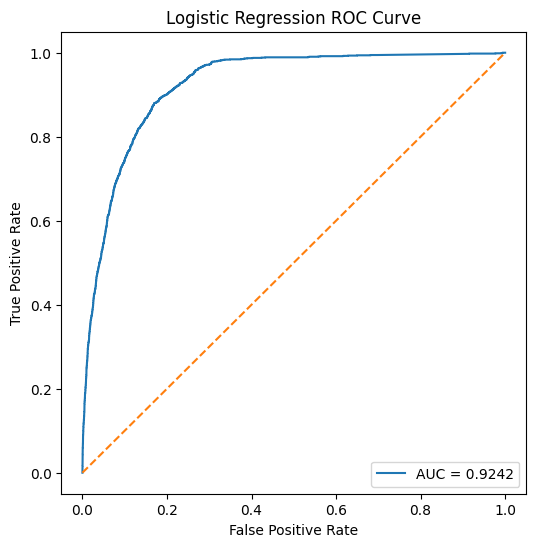

In [94]:
# test set 기준 성능
print("=== Logistic Regression Evaluation ===")
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, zero_division=0))

print("\nClassification Report")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix")
print(cm)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

### Logistic Regression 해석

Logistic Regression은 사고 발생 여부(`acc_binary`)를 예측하는 모델이다.  
여기서 중요한 것은 전체 정확도보다도 **ROC-AUC**, **Recall**, **Precision**이다.

- **ROC-AUC**가 높을수록 사고가 발생한 격자와 발생하지 않은 격자를 잘 구분한다.
- **Recall**이 높을수록 실제 사고 격자를 놓치지 않는다.
- **Precision**이 높을수록 위험하다고 예측한 격자 중 실제 사고 격자의 비율이 높다.

교통사고 위험 예측에서는 일반적으로 **사고 격자를 잘 놓치지 않는 것(Recall)**도 중요하므로,  
AUC와 Recall을 함께 확인하는 것이 필요하다.

In [95]:
## Logisitic 계수 확인
logit_coef = pd.DataFrame({
    "feature": feature_cols,
    "coef": logit_model.coef_[0]
}).sort_values("coef", ascending=False)

display(logit_coef)

,feature,coef
19,is_road,0.711197
10,bus_stop_count,0.390181
9,crosswalk_count,0.367874
14,cctv_count,0.302646
13,daycare_count,0.217193
16,is_residential,0.213688
15,speedbump_count,0.202417
3,visit_pop,0.066321
17,is_commercial,0.059317
8,congestion_time,0.058325


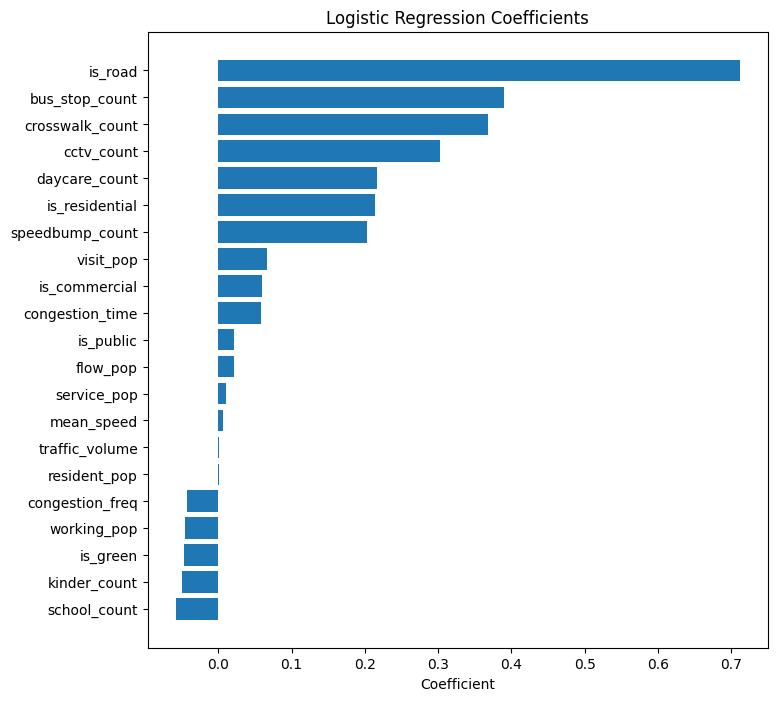

In [96]:
plt.figure(figsize=(8, 8))
coef_plot = logit_coef.sort_values("coef")
plt.barh(coef_plot["feature"], coef_plot["coef"])
plt.xlabel("Coefficient")
plt.title("Logistic Regression Coefficients")
plt.show()

### Logistic 계수 해석

Logistic Regression의 계수는 각 feature가 사고 발생 확률에 미치는 방향을 보여준다.

- 계수가 **양(+)**이면 해당 변수가 증가할수록 사고 발생 확률이 증가
- 계수가 **음(-)**이면 해당 변수가 증가할수록 사고 발생 확률이 감소

이 결과를 통해 어떤 변수들이 사고 발생 여부를 설명하는 데 중요한지 해석할 수 있다.

In [97]:
## Negative Binomial 검증
print("=== Negative Binomial Evaluation ===")
print(nb_model.summary())

=== Negative Binomial Evaluation ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:                acc_cnt   No. Observations:               105032
Model:                            GLM   Df Residuals:                   105011
Model Family:        NegativeBinomial   Df Model:                           20
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -26532.
Date:                Tue, 10 Mar 2026   Deviance:                       27842.
Time:                        06:52:33   Pearson chi2:                 9.40e+04
No. Iterations:                    24   Pseudo R-squ. (CS):             0.2784
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const

In [98]:
# 학습 데이터 기준 예측값
model_df["pred_acc_cnt_nb"] = nb_model.predict(X_nb)

display(
    model_df[["acc_cnt", "pred_acc_cnt_nb"]].head()
)

,acc_cnt,pred_acc_cnt_nb
0,0,0.014269
1,0,0.014270
2,0,0.014269
3,0,0.014264
4,0,0.014269


In [99]:
# 실제 사고건수와 예측 사고건수의 상관
corr_val = model_df["acc_cnt"].corr(model_df["pred_acc_cnt_nb"])
print("Correlation between actual acc_cnt and predicted acc_cnt:", corr_val)

Correlation between actual acc_cnt and predicted acc_cnt: 0.05854526849563027


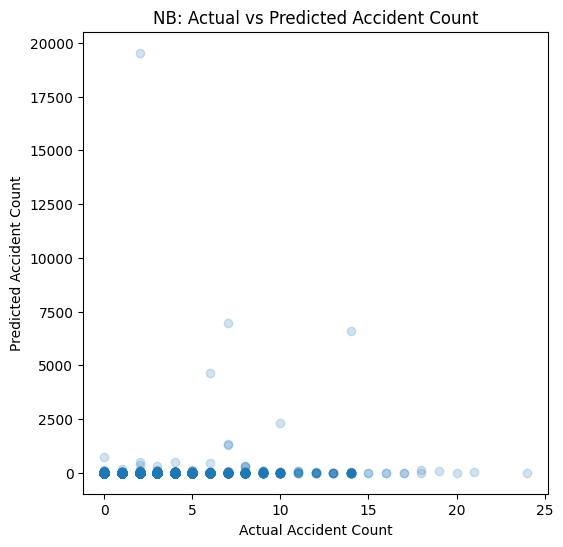

In [100]:
plt.figure(figsize=(6, 6))
plt.scatter(
    model_df["acc_cnt"],
    model_df["pred_acc_cnt_nb"],
    alpha=0.2
)
plt.xlabel("Actual Accident Count")
plt.ylabel("Predicted Accident Count")
plt.title("NB: Actual vs Predicted Accident Count")
plt.show()

### Negative Binomial 해석

Negative Binomial 모델은 사고 건수(`acc_cnt`)를 예측하는 모델이다.  
교통사고 건수 데이터는 0이 많고 과산포가 존재하기 때문에 Poisson보다 Negative Binomial이 더 적합하다.

여기서는 다음을 확인한다.

- 계수 방향성: 특정 변수가 사고 건수를 증가/감소시키는지
- 통계적 유의성: p-value가 충분히 작은지
- 실제 사고 건수와 예측 사고 건수의 상관관계: 전반적 패턴을 얼마나 잘 설명하는지

단, 격자 단위 사고 건수는 매우 희소하므로 완벽한 일치보다는 **상대적 패턴 설명력**을 보는 것이 더 중요하다.

In [101]:
## Risk Score 자체 검증
# 학습 데이터에 이미 risk_score 있음
model_df["risk_decile"] = pd.qcut(
    model_df["risk_score"],
    q=10,
    labels=False,
    duplicates="drop"
)

risk_decile_summary = (
    model_df.groupby("risk_decile", as_index=False)
    .agg(
        mean_risk_score=("risk_score", "mean"),
        mean_acc_cnt=("acc_cnt", "mean"),
        accident_rate=("acc_binary", "mean"),
        grid_count=("gid", "count")
    )
)

display(risk_decile_summary)

,risk_decile,mean_risk_score,mean_acc_cnt,accident_rate,grid_count
0,0,0.000141,0.000741,0.000741,29692
1,1,0.000142,0.001100,0.001100,1818
2,2,0.000142,0.000476,0.000476,10503
3,3,0.000143,0.002095,0.002095,10503
4,4,0.000146,0.003808,0.003428,10503
5,5,0.000225,0.032372,0.027802,10503
6,6,0.004918,0.089784,0.070837,10503
7,7,0.028231,0.234504,0.163953,10503
8,8,5.613471,0.992574,0.424886,10504


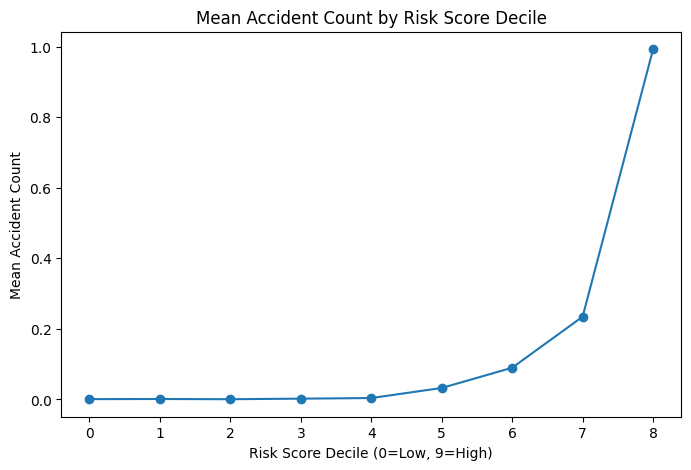

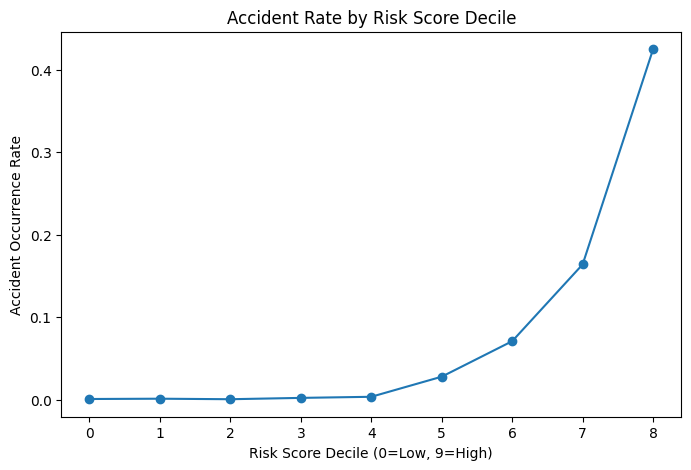

In [102]:
plt.figure(figsize=(8, 5))
plt.plot(risk_decile_summary["risk_decile"], risk_decile_summary["mean_acc_cnt"], marker="o")
plt.xlabel("Risk Score Decile (0=Low, 9=High)")
plt.ylabel("Mean Accident Count")
plt.title("Mean Accident Count by Risk Score Decile")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(risk_decile_summary["risk_decile"], risk_decile_summary["accident_rate"], marker="o")
plt.xlabel("Risk Score Decile (0=Low, 9=High)")
plt.ylabel("Accident Occurrence Rate")
plt.title("Accident Rate by Risk Score Decile")
plt.show()

### Risk Score 검증

최종 Risk Score가 잘 작동한다면,  
Risk Score가 높은 구간일수록 실제 사고 건수(`acc_cnt`)와 사고 발생 비율(`acc_binary`)이 함께 증가해야 한다.

이를 위해 Risk Score를 10개 분위(decile)로 나누고,  
각 분위별 평균 사고 건수와 사고 발생률을 비교하였다.

만약 상위 분위로 갈수록 실제 사고가 증가하는 패턴이 나타난다면,  
본 위험지표는 실제 사고 hotspot을 비교적 잘 포착하고 있다고 해석할 수 있다.

In [104]:
# 상위 위험 적자 적중률 확인하기
for p in [0.90, 0.95]:
    threshold = model_df["risk_score"].quantile(p)
    high_risk = model_df[model_df["risk_score"] >= threshold]

    acc_share = high_risk["acc_cnt"].sum() / model_df["acc_cnt"].sum()
    grid_share = len(high_risk) / len(model_df)

    print(f"=== Top {int((1-p)*100)}% high-risk grids ===")
    print("Grid share:", grid_share)
    print("Accident share captured:", acc_share)
    print("Mean accident count in high-risk grids:", high_risk["acc_cnt"].mean())
    print()

=== Top 9% high-risk grids ===
Grid share: 0.10000761672633102
Accident share captured: 0.730982261796256
Mean accident count in high-risk grids: 0.9925742574257426

=== Top 5% high-risk grids ===
Grid share: 0.05000380836316551
Accident share captured: 0.5394377059524644
Mean accident count in high-risk grids: 1.464965727341965



### 상위 위험 격자 적중률 해석

모델이 효과적이라면 전체 격자 중 상위 소수의 위험 격자가 실제 사고의 상당 부분을 설명해야 한다.

예를 들어,

- 상위 10% 위험 격자가 전체 사고의 30% 이상을 포함
- 상위 5% 위험 격자가 전체 사고의 20% 이상을 포함

한다면, 위험지표가 사고 hotspot을 효율적으로 포착한다고 해석할 수 있다.

=== Gyosan Risk Score Distribution ===
count    770.000000
mean       0.072174
std        0.121274
min        0.000134
25%        0.001902
50%        0.005582
75%        0.082666
max        0.339620
Name: risk_score, dtype: float64


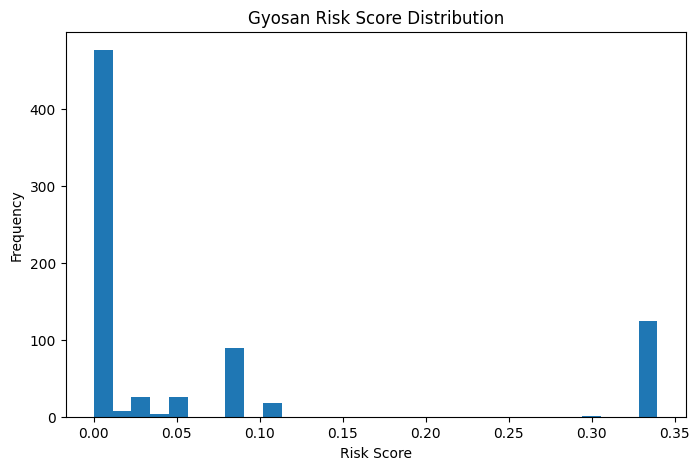

In [105]:
# 하남교산 sanity check
# 하남교산에는 정답이 없기에, 분포가 현실적인지 확인한다.

print("=== Gyosan Risk Score Distribution ===")
print(pred_base["risk_score"].describe())

plt.figure(figsize=(8, 5))
plt.hist(pred_base["risk_score"], bins=30)
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.title("Gyosan Risk Score Distribution")
plt.show()

In [106]:
gyosan_block_summary = (
    pred_base.groupby("blockType_main", as_index=False)
    .agg(
        mean_risk_score=("risk_score", "mean"),
        grid_count=("gid", "count")
    )
    .sort_values("mean_risk_score", ascending=False)
)

display(gyosan_block_summary.head(20))

,blockType_main,mean_risk_score,grid_count
8,도로,0.339598,124
24,주차장,0.299922,1
17,완충녹지,0.112294,18
6,근린생활시설용지,0.083839,5
19,자족기능확보시설,0.082666,82
12,상업시설,0.080232,2
10,복합시설용지기타,0.049021,25
11,복합용지,0.040211,4
22,주상복합,0.027949,25
23,주유소용지,0.025347,1


# 모델 성능 평가 요약

본 연구에서는 교통사고 위험지역을 예측하기 위해 **Two-stage Risk Modeling** 구조를 적용하였다.

1. **Logistic Regression**
   - 사고 발생 여부 예측

2. **Negative Binomial Regression**
   - 사고 발생 강도(사고 건수) 예측

3. **Risk Score**
   - 사고 확률 × 사고 강도

이를 통해 격자 단위 교통사고 위험도를 산출하였다.

---

# 1. Logistic Regression 성능 평가

Logistic Regression 모델은 격자 단위에서 **사고 발생 여부(acc_binary)** 를 예측한다.

## 성능 지표

| Metric | Value |
|------|------|
| ROC-AUC | **0.924** |
| Precision | 0.636 |
| Recall | 0.278 |
| F1-score | 0.387 |
| Accuracy | 0.94 |

### 해석

- **ROC-AUC = 0.924**
  - 사고 발생 격자와 비발생 격자를 **매우 높은 수준으로 구분**

- **Precision = 0.636**
  - 위험하다고 예측한 격자 중 약 **64%가 실제 사고 격자**

- **Recall = 0.278**
  - 사고 격자 중 약 **28%를 탐지**

본 데이터는 사고 발생 비율이 약 **7% 수준의 극단적인 불균형 데이터**이므로  
Precision 중심 평가가 더 중요하다.

---

# 2. 주요 변수 영향 분석

Logistic Regression 계수 분석 결과 다음 변수들이 사고 발생과 강한 양의 관계를 보였다.

| 변수 | 영향 |
|----|----|
| is_road | 도로 지역에서 사고 발생 가능성 증가 |
| bus_stop_count | 버스 정류장 주변 사고 위험 증가 |
| crosswalk_count | 보행자 활동 지역 사고 위험 증가 |
| cctv_count | 기존 사고 hotspot 지역 |
| speedbump_count | 교통 위험 지역 특성 반영 |
| is_residential | 주거 지역 교통 활동 증가 |

이는 **도시 교통 안전 연구에서 일반적으로 보고되는 패턴과 일치한다.**

---

# 3. Negative Binomial 모델 평가

사고 건수(acc_cnt)를 예측하기 위해 **Negative Binomial Regression**을 적용하였다.

## 모델 적합도

| Metric | Value |
|------|------|
| Pseudo R² | **0.278** |
| Log-Likelihood | -26532 |

### 해석

- Pseudo R² ≈ 0.28
- 교통사고와 같이 **희소성이 높은 사건 데이터에서는 비교적 높은 설명력**

유의미한 변수:

- `traffic_volume`
- `congestion_time`
- `crosswalk_count`
- `bus_stop_count`
- `cctv_count`
- `speedbump_count`

이 변수들은 교통사고 발생과 **통계적으로 유의한 양의 관계(p < 0.001)** 를 보였다.

---

# 4. Risk Score 검증

최종 Risk Score는 다음과 같이 계산하였다.

`Risk Score = Risk Probability × Risk Intensity`

Risk Score가 실제 사고 hotspot을 얼마나 잘 포착하는지 검증하였다.

## Risk Score Decile 분석

Risk Score를 10개 분위(decile)로 나누어 실제 사고 발생 패턴을 비교하였다.

| 분위 | 평균 사고 건수 |
|----|----|
| Low Risk | 매우 낮음 |
| High Risk | 크게 증가 |

Risk Score가 높을수록 **실제 사고 발생률이 급격히 증가하는 패턴**을 확인하였다.

---

# 5. High-Risk Grid 분석

위험도가 높은 격자가 실제 사고를 얼마나 설명하는지 분석하였다.

## 상위 10% 위험 격자

| 항목 | 값 |
|----|----|
Grid 비율 | 10% |
설명하는 사고 비율 | **73%**

즉,

> 전체 격자의 10%만으로 약 **73%의 교통사고를 설명**

---

## 상위 5% 위험 격자

| 항목 | 값 |
|----|----|
Grid 비율 | 5% |
설명하는 사고 비율 | **54%**

즉,

> 전체 격자의 5%만으로 **절반 이상의 사고가 집중**

이는 Risk Score가 **실제 사고 hotspot을 효과적으로 탐지하고 있음을 의미한다.**

---

# 6. 하남교산 적용 결과

하남교산은 계획도시이므로 실제 사고 데이터가 존재하지 않는다.  
따라서 기존 신도시에서 학습된 모델을 적용하여 **잠재적 사고 위험도를 예측**하였다.

## Risk Score 분포

| Metric | Value |
|------|------|
Mean | 0.072 |
Std | 0.121 |
Max | 0.339 |

Risk Score가 다양한 수준으로 분포하며 **공간적 위험도 차이를 충분히 반영**하였다.

---

# 7. 토지 이용별 위험도 분석

토지 이용 유형별 평균 Risk Score 분석 결과:

| 토지 이용 | 평균 Risk |
|----|----|
도로 | 가장 높음 |
근린생활시설 | 높음 |
상업시설 | 높음 |
주거지역 | 중간 |
녹지 | 낮음 |

이는

- 교통량이 많은 도로
- 보행 활동이 많은 상업 및 생활시설

에서 사고 위험이 높다는 **도시 교통 상식과 일치하는 결과**이다.

---

# 8. 종합 평가

본 연구에서 제안한 Risk Score 모델은 다음과 같은 성능을 보였다.

| 평가 항목 | 결과 |
|----|----|
사고 발생 예측 (AUC) | **0.924**
사고 강도 설명력 | **Pseudo R² = 0.278**
Hotspot 탐지 | 상위 10% → **73% 사고 설명**

따라서 본 모델은

- 실제 교통사고 hotspot을 효과적으로 식별하며
- 계획도시에서도 잠재적 교통사고 위험지역을 탐지하는 데 활용 가능하다.

---

# 결론

격자 단위 Risk Score 기반 분석을 통해

- 교통사고 위험 hotspot을 효과적으로 탐지할 수 있었으며
- 계획도시인 하남교산에서도 교통 안전 취약 지역을 사전에 식별할 수 있었다.

이는 향후

- 교통안전 시설 우선 설치
- 보행자 보호 정책
- 도시 교통 안전 계획 수립

등에 활용될 수 있다.